# **Séries Temporelles**

## Télécharger les packages

In [68]:
!pip3 install eurostat numpy pandas matplotlib dataframe_image statsmodels plotly kaleido seaborn polars

In [69]:
!pip3 list

Package                   Version
------------------------- -----------
aiohappyeyeballs          2.6.1
aiohttp                   3.11.18
aiosignal                 1.3.2
altair                    5.5.0
appnope                   0.1.4
asttokens                 3.0.0
attrs                     25.3.0
beautifulsoup4            4.13.4
bleach                    6.2.0
certifi                   2025.1.31
charset-normalizer        3.4.1
cloudpickle               3.1.1
comm                      0.2.2
contourpy                 1.3.1
cssselect                 1.3.0
cssutils                  2.11.1
cycler                    0.12.1
dataframe_image           0.2.7
debugpy                   1.8.13
decorator                 5.2.1
defusedxml                0.7.1
docx                      0.2.4
et_xmlfile                2.0.0
eurostat                  1.1.1
executing                 2.2.0
factor_analyzer           0.5.1
fastjsonschema            2.21.1
fonttools                 4.56.0
frozenlist         

## Mobilisation des packages

In [70]:
import os
import eurostat
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import statsmodels.api as sm
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import acf, pacf, adfuller, add_trend,grangercausalitytests

## Chemin d'accès

In [71]:
os.chdir('/Users/marius/Desktop/M1/Serie Temporelle/Projet avec python')
print(os.getcwd())

/Users/marius/Desktop/M1/Serie Temporelle/Projet avec python


# PARTIE 1 : 
## Récupérer les données issus d'Eurostat

### Série Exportation (X)

In [72]:
X = eurostat.get_data_df('namq_10_exi')
X = X[(X['unit'] == 'CLV10_MEUR')&(X['na_item'] == 'P6')&(X['s_adj'] == 'SCA')&(X['geo\TIME_PERIOD'] == 'LU')]
X = X.dropna(axis=1)
X = X.iloc[:, 5:]
X = X.T
X = X.rename(columns={X.columns[0]:'X'})
X = np.log(X)
X = X.head(120)
# Version en différence de la série exportation
X_diff = X.diff().dropna()

<>:2: SyntaxWarning: invalid escape sequence '\T'
<>:2: SyntaxWarning: invalid escape sequence '\T'
/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_9941/724052957.py:2: SyntaxWarning: invalid escape sequence '\T'
  X = X[(X['unit'] == 'CLV10_MEUR')&(X['na_item'] == 'P6')&(X['s_adj'] == 'SCA')&(X['geo\TIME_PERIOD'] == 'LU')]


### Série Importation (M)

In [73]:
M = eurostat.get_data_df('namq_10_exi')
M = M[(M['unit'] == 'CLV10_MEUR')&(M['na_item'] == 'P7')&(M['s_adj'] == 'SCA')&(M['geo\TIME_PERIOD'] == 'LU')]
M = M.dropna(axis=1)
M = M.iloc[:, 5:]
M = M.T
M = M.rename(columns={M.columns[0]:'M'})
M = np.log(M)
M = M.head(120)
# Version en différence de la série importation
M_diff = M.diff().dropna()

<>:2: SyntaxWarning: invalid escape sequence '\T'
<>:2: SyntaxWarning: invalid escape sequence '\T'
/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_9941/4002899004.py:2: SyntaxWarning: invalid escape sequence '\T'
  M = M[(M['unit'] == 'CLV10_MEUR')&(M['na_item'] == 'P7')&(M['s_adj'] == 'SCA')&(M['geo\TIME_PERIOD'] == 'LU')]


## Exportation vers Excel

## Graphiques

### Pour le tableau de la FAC et FAP

In [74]:
X_fac = acf(X, adjusted=0, nlags=32, qstat=True, fft=True, alpha=None, bartlett_confint=True, missing='none')
XT = pd.DataFrame(X_fac).T.rename(columns={0:'FAC',1:'Q-stat',2:'Prob'})
X_fap = pacf(X, nlags=32, method='ywmle', alpha=None)
XTFAP = pd.DataFrame(X_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0:'FAP'})
XT.insert(1, "FAP", XTFAP )
XT.iloc[:, 0] = XT.iloc[:, 0].shift(-1)
XT = XT.drop(XT.index[-1]).reset_index(drop=True)
 
XT[['FAC', 'FAP', 'Prob']] = XT[['FAC', 'FAP','Prob']].round(3)
 
XT[['Q-stat']] = XT[['Q-stat']].round(2)

XT.insert(0, 'Lag', range(1, len(XT) + 1))

In [75]:
X_fac = acf(X_diff, adjusted=0, nlags=32, qstat=True, fft=True, alpha=None, bartlett_confint=True, missing='none')
XTD = pd.DataFrame(X_fac).T.rename(columns={0:'FAC',1:'Q-stat',2:'Prob'})
X_fap = pacf(X_diff, nlags=32, method='ywmle', alpha=None)
XTDFAP = pd.DataFrame(X_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0:'FAP'})
XTD.insert(1, "FAP", XTDFAP )
XTD.iloc[:, 0] = XTD.iloc[:, 0].shift(-1)
XTD = XTD.drop(XTD.index[-1]).reset_index(drop=True)
 
XTD[['FAC', 'FAP', 'Prob']] = XTD[['FAC', 'FAP','Prob']].round(3)
 
XTD[['Q-stat']] = XTD[['Q-stat']].round(2)

XTD.insert(0, 'Lag', range(1, len(XTD) + 1))


#XTD.to_excel("XTDiff.xlsx", index=False)

In [76]:
M_fac = acf(M, adjusted=0, nlags=32, qstat=True, fft=True, alpha=None, bartlett_confint=True, missing='none')
MT = pd.DataFrame(M_fac).T.rename(columns={0:'FAC',1:'Q-stat',2:'Prob'})
M_fap = pacf(M, nlags=32, method='ywmle', alpha=None)
MTFAP = pd.DataFrame(M_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0:'FAP'})
MT.insert(1, "FAP", MTFAP )
MT.iloc[:, 0] = MT.iloc[:, 0].shift(-1)
MT = MT.drop(MT.index[-1]).reset_index(drop=True)

MT[['FAC', 'FAP', 'Prob']] = MT[['FAC', 'FAP','Prob']].round(3)
 
MT[['Q-stat']] = MT[['Q-stat']].round(2)

MT.insert(0, 'Lag', range(1, len(MT) + 1))

In [77]:
M_fac = acf(M_diff, adjusted=0, nlags=32, qstat=True, fft=True, alpha=None, bartlett_confint=True, missing='none')
MTD = pd.DataFrame(M_fac).T.rename(columns={0:'FAC',1:'Q-stat',2:'Prob'})
M_fap = pacf(M_diff, nlags=32, method='ywmle', alpha=None)
MTDFAP = pd.DataFrame(M_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0:'FAP'})
MTD.insert(1, "FAP", MTDFAP )
MTD.iloc[:, 0] = MTD.iloc[:, 0].shift(-1)
MTD = MTD.drop(MTD.index[-1]).reset_index(drop=True)

MTD[['FAC', 'FAP', 'Prob']] = MTD[['FAC', 'FAP','Prob']].round(3)
 
MTD[['Q-stat']] = MTD[['Q-stat']].round(2)

MTD.insert(0, 'Lag', range(1, len(MTD) + 1))

#MTD.to_excel("MTDiff.xlsx", index=False)

### Transformation des données des deux séries pour le graphique

In [78]:
XM = pd.concat([X]+[M], axis=1)
XM = XM.rename(columns={'X':'lnX','M':'lnM'})
XM.index = pd.date_range(start="1995-01-01", periods=120, freq="QS")
XM.index = pd.to_datetime(XM.index)

/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_9941/1107912299.py:52: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  plt.xticks(pd.date_range(start="1995", periods=31, freq="Y"), fontsize=12, rotation=45)


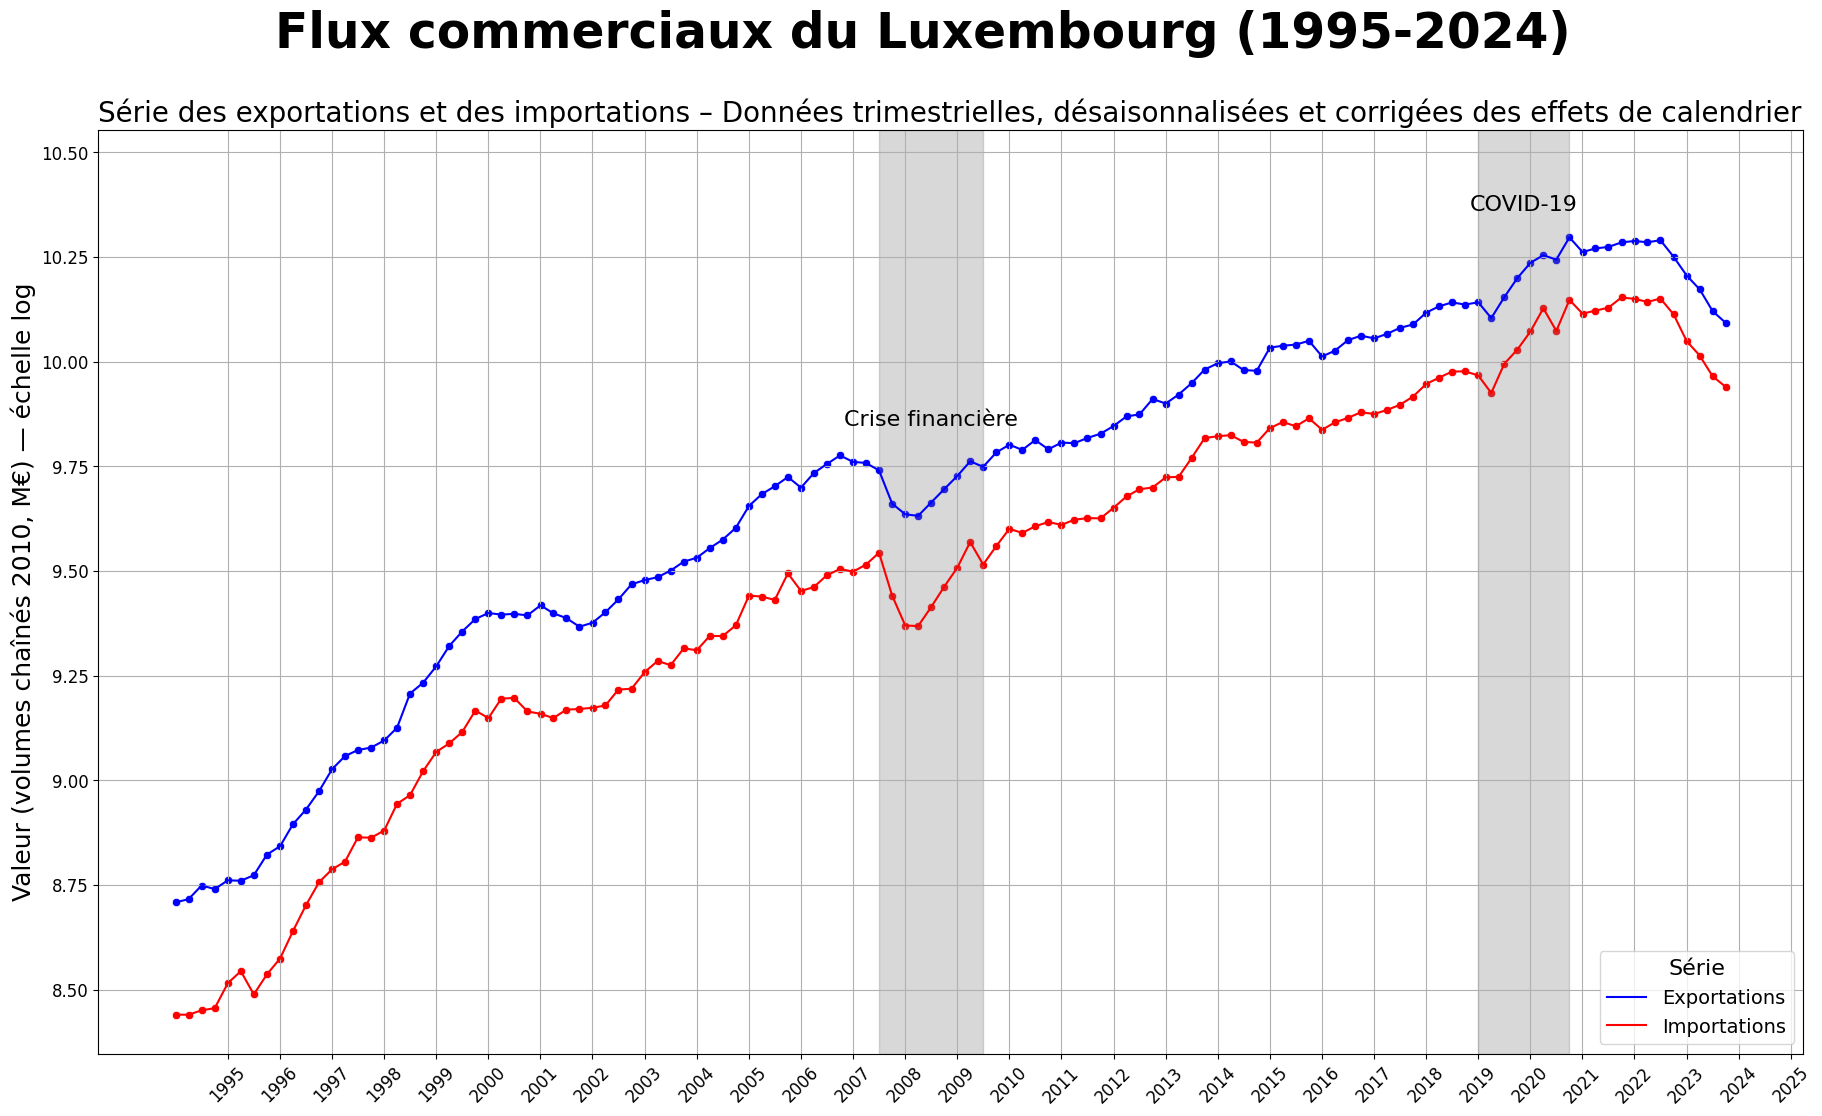

In [79]:
# Création de la figure et des axes
plt.figure(figsize=(22, 12))

# Tracé des courbes
sns.lineplot(data=XM, x=XM.index, y='lnX', color='blue', label='Exportations')
sns.scatterplot(data=XM, x=XM.index, y='lnX', color='blue')

sns.lineplot(data=XM, x=XM.index, y='lnM', color='red', label='Importations')
sns.scatterplot(data=XM, x=XM.index, y='lnM', color='red')

plt.ylim(top=XM[['lnX', 'lnM']].max().max() * 1.025)

# Zones grisées pour les crises
crise_fin_start = pd.Timestamp("2008-07-01")
crise_fin_end = pd.Timestamp("2010-06-30")
covid_start = pd.Timestamp("2020-01-01")
covid_end = pd.Timestamp("2021-09-30")

plt.axvspan(crise_fin_start, crise_fin_end, color='grey', alpha=0.3)
plt.axvspan(covid_start, covid_end, color='grey', alpha=0.3)

# Annotation des crises
plt.text(x=crise_fin_start + (crise_fin_end - crise_fin_start) / 2,
         y=XM[['lnX', 'lnM']].max().max() * 0.96,
         s="Crise financière",
         fontsize=16,
         ha='center',
         va='top',
         color='black')

plt.text(x=covid_start + (covid_end - covid_start) / 2,
         y=XM[['lnX', 'lnM']].max().max() * 1.01,
         s="COVID-19",
         fontsize=16,
         ha='center',
         va='top',
         color='black')

# Ajout du titre et des labels
plt.xlabel(None)
plt.ylabel("Valeur (volumes chaînés 2010, M€) — échelle log", fontsize=18)
plt.title("Série des exportations et des importations – Données trimestrielles, désaisonnalisées et corrigées des effets de calendrier",
          fontsize=20, loc='left')
plt.suptitle("Flux commerciaux du Luxembourg (1995-2024)", fontsize=35, fontweight='bold')

# Légende
plt.legend(title="Série", title_fontsize=16, fontsize=14, loc='lower right', bbox_to_anchor=(1, 0))

plt.grid(True)

# Personnalisation des axes
plt.xticks(pd.date_range(start="1995", periods=31, freq="Y"), fontsize=12, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.yticks(fontsize=12)

# Affichage
plt.show()

### FAC et FAP (niveau et différence)

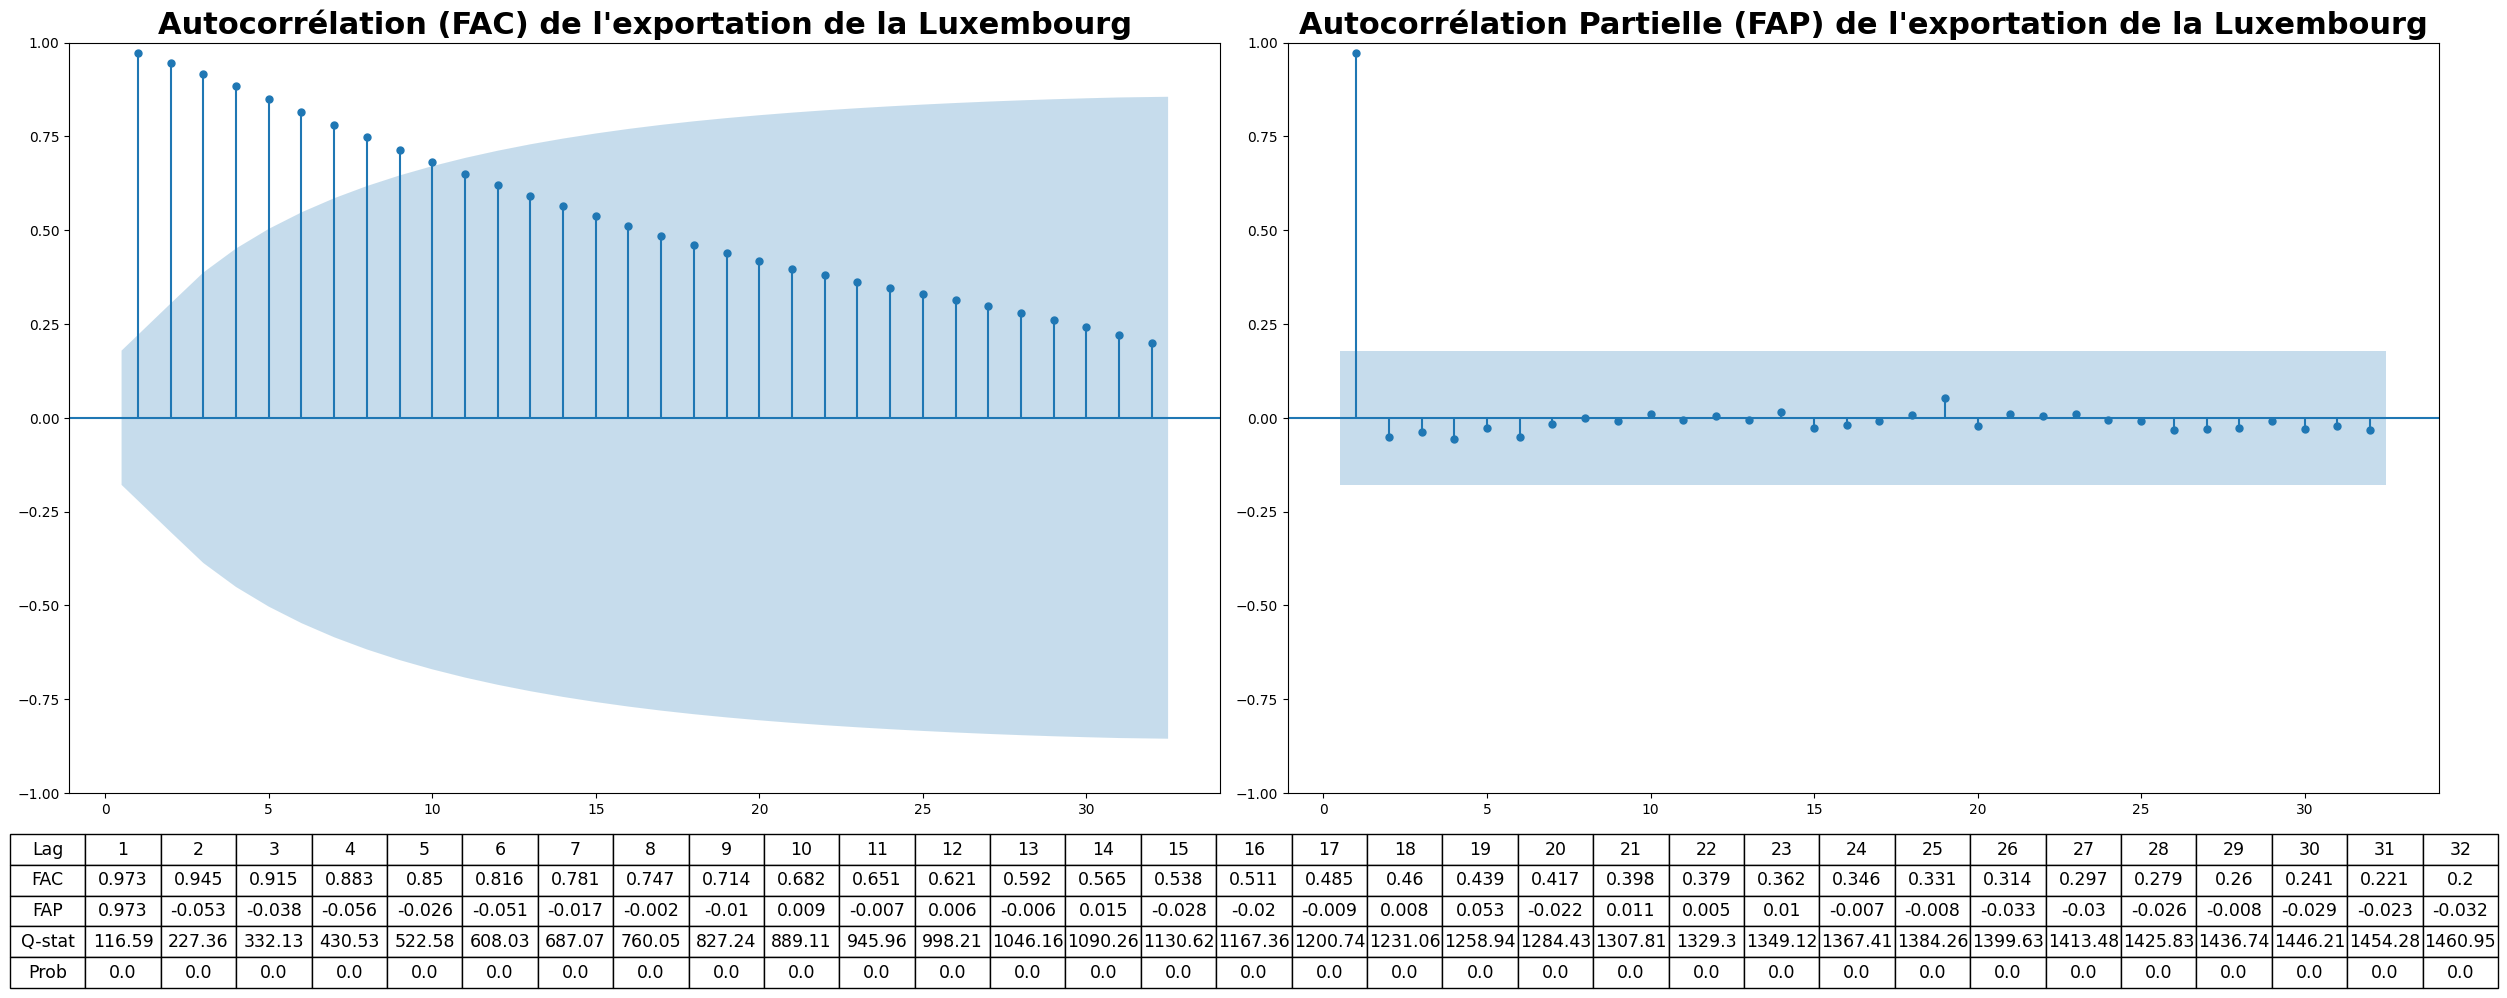

In [80]:
XG = XT.set_index('Lag').T
XG = XG.reset_index().rename(columns={'index': 'Lag'})  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(X, lags=32, zero=False,
                         title="Autocorrélation (FAC) de l'exportation de la Luxembourg", ax=ax0)
ax0.set_title("Autocorrélation (FAC) de l'exportation de la Luxembourg", fontsize=22, fontweight='bold')
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(X, lags=32, zero=False,
                          title="Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg", ax=ax1)
ax1.set_title("Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg", fontsize=22, fontweight='bold')
# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis('off')

table = ax2.table(cellText=XG.values,
                  colLabels=XG.columns,
                  cellLoc='center',
                  loc='upper center')
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
#plt.savefig('XGraph+Table.png', bbox_inches='tight')
plt.show()

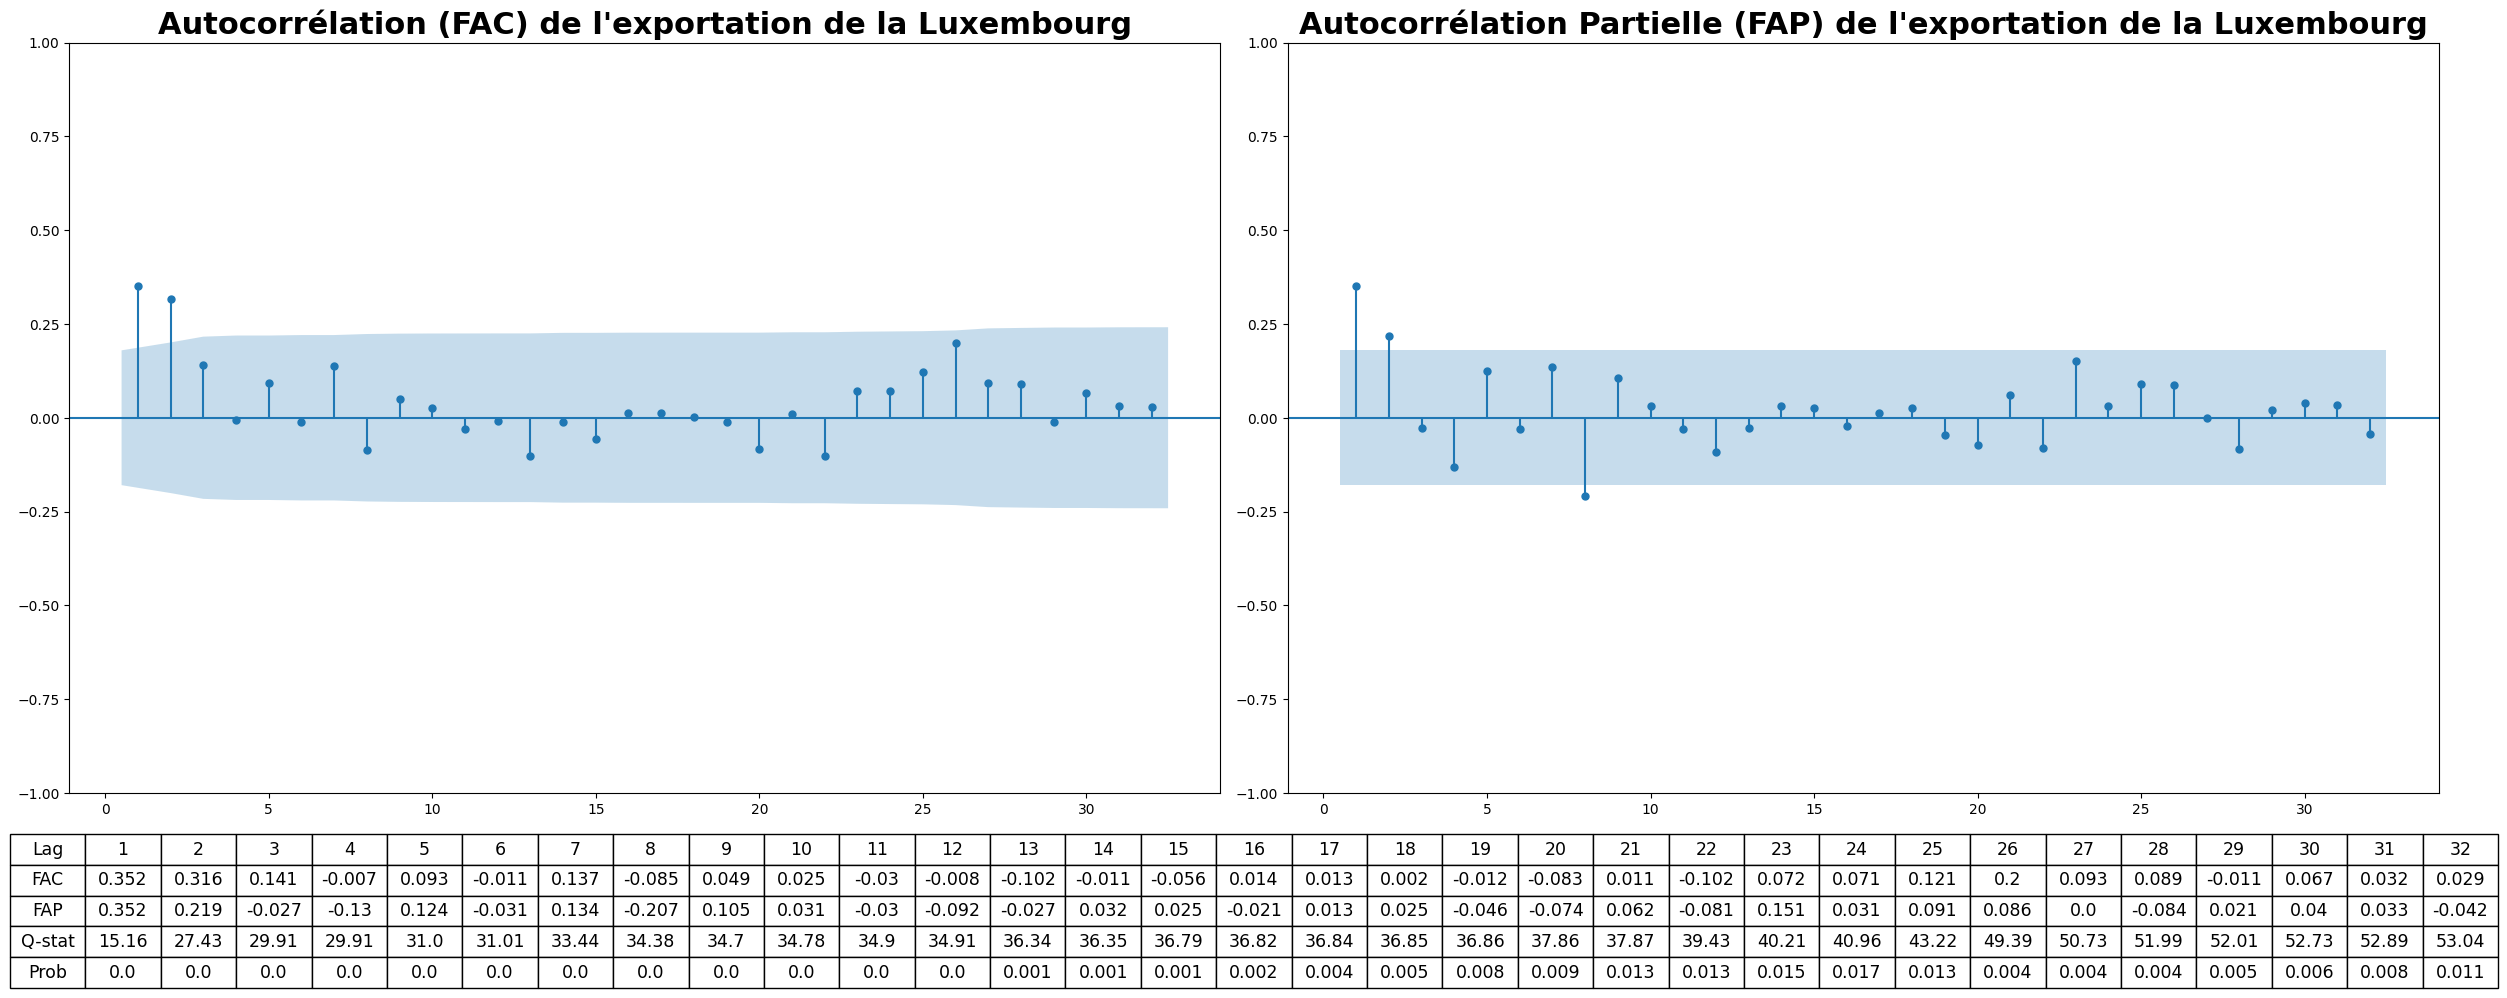

In [81]:
XDG = XTD.set_index('Lag').T
XDG = XDG.reset_index().rename(columns={'index': 'Lag'})  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(X_diff, lags=32, zero=False,
                         title="Autocorrélation (FAC) de l'exportation de la Luxembourg", ax=ax0)
ax0.set_title("Autocorrélation (FAC) de l'exportation de la Luxembourg", fontsize=22, fontweight='bold')
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(X_diff, lags=32, zero=False,
                          title="Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg", ax=ax1)
ax1.set_title("Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg", fontsize=22, fontweight='bold')
# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis('off')

table = ax2.table(cellText=XDG.values,
                  colLabels=XDG.columns,
                  cellLoc='center',
                  loc='upper center')
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
#plt.savefig('XDiffGraph+Table.png', bbox_inches='tight')
plt.show()

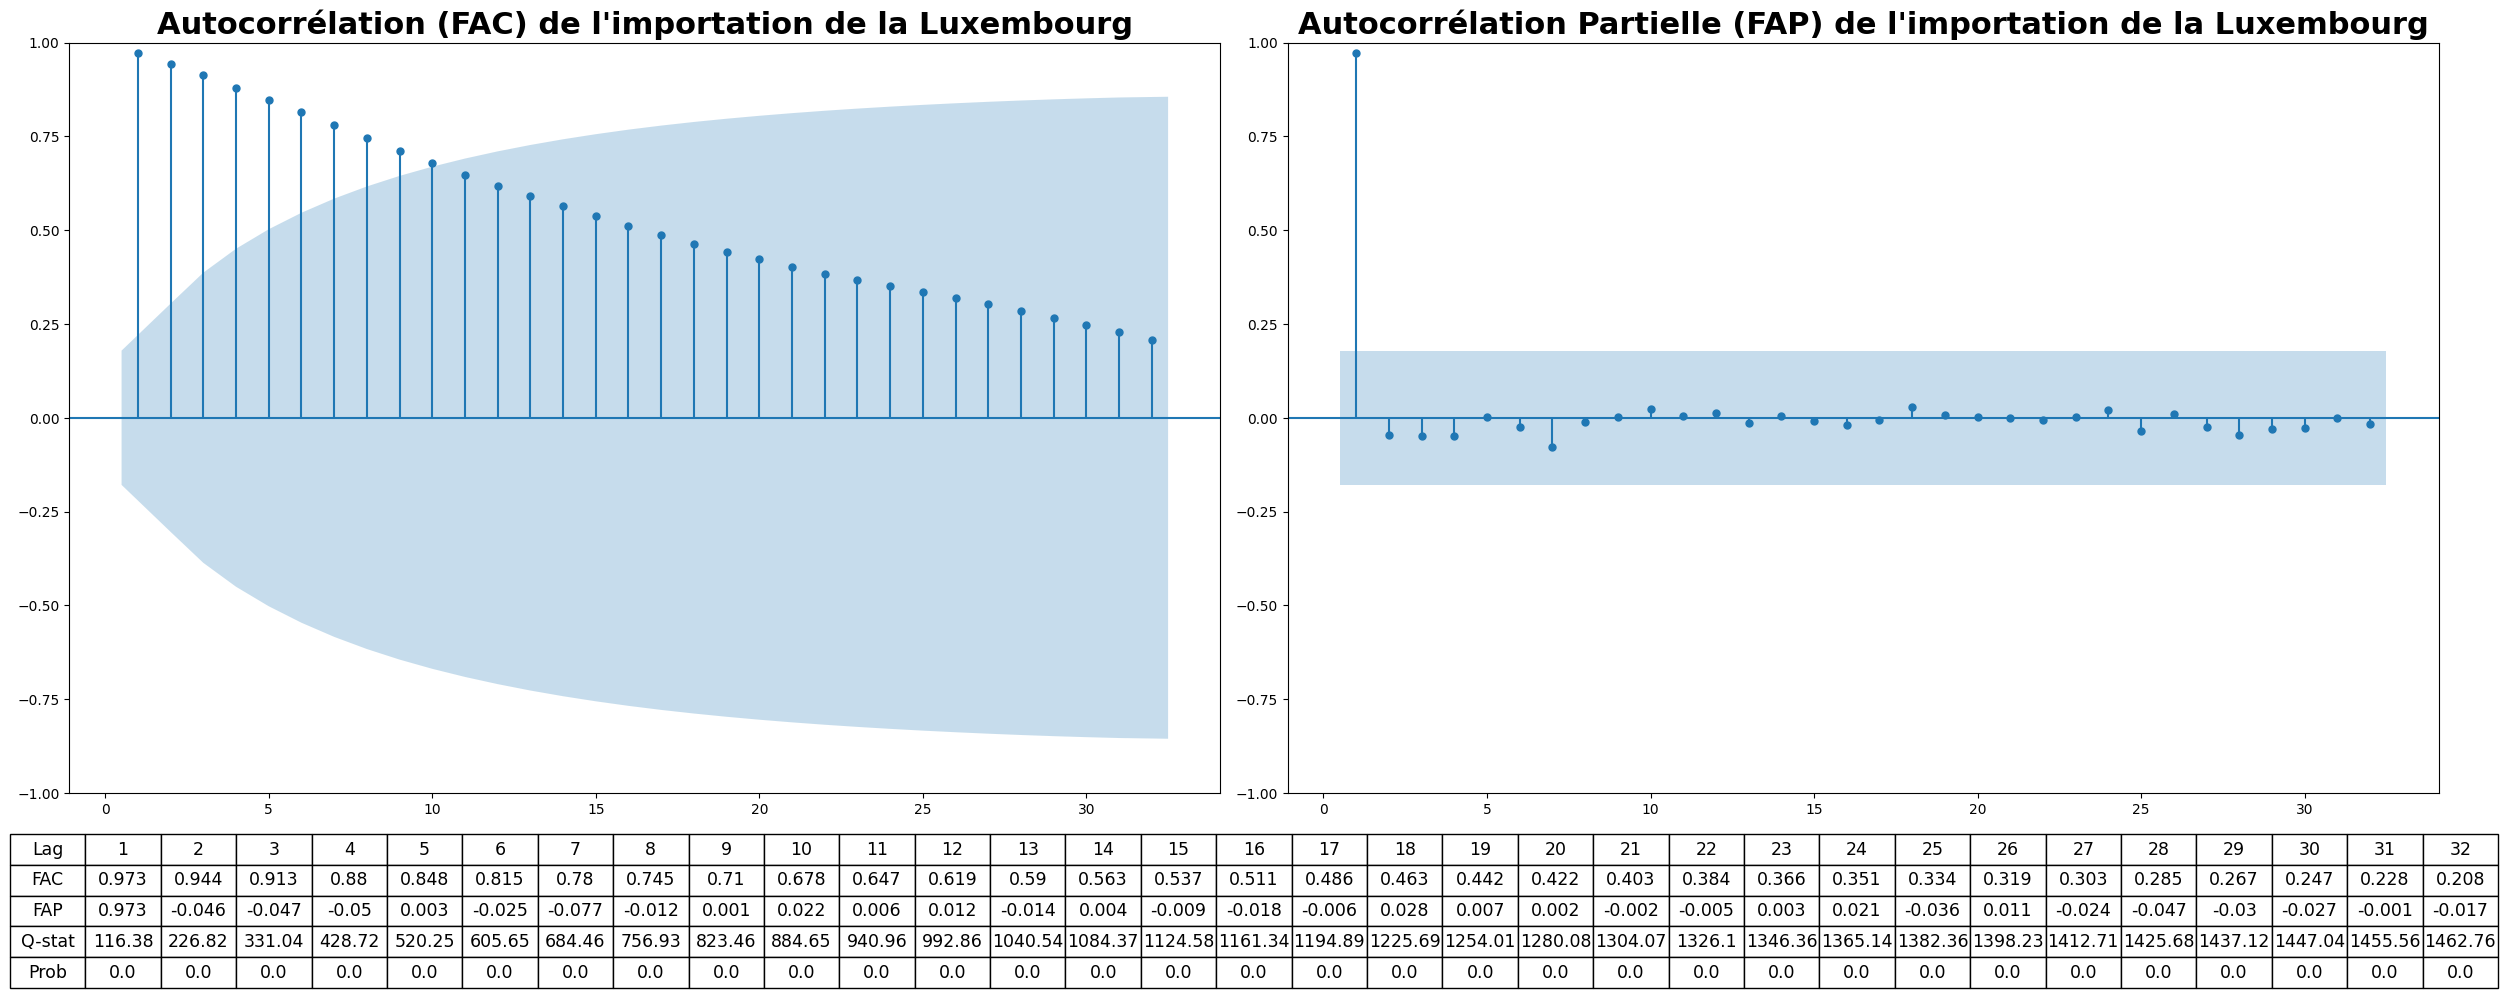

In [82]:
MG = MT.set_index('Lag').T
MG = MG.reset_index().rename(columns={'index': 'Lag'})  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(M, lags=32, zero=False,
                         title="Autocorrélation (FAC) de l'importation de la Luxembourg", ax=ax0)
ax0.set_title("Autocorrélation (FAC) de l'importation de la Luxembourg", fontsize=22, fontweight='bold')
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(M, lags=32, zero=False,
                          title="Autocorrélation Partielle (FAP) de l'importation de la Luxembourg", ax=ax1)
ax1.set_title("Autocorrélation Partielle (FAP) de l'importation de la Luxembourg", fontsize=22, fontweight='bold')

# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis('off')

table = ax2.table(cellText=MG.values,
                  colLabels=MG.columns,
                  cellLoc='center',
                  loc='upper center')
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)
plt.tight_layout()
#plt.savefig('MGraph+Table.png', bbox_inches='tight')
plt.show()

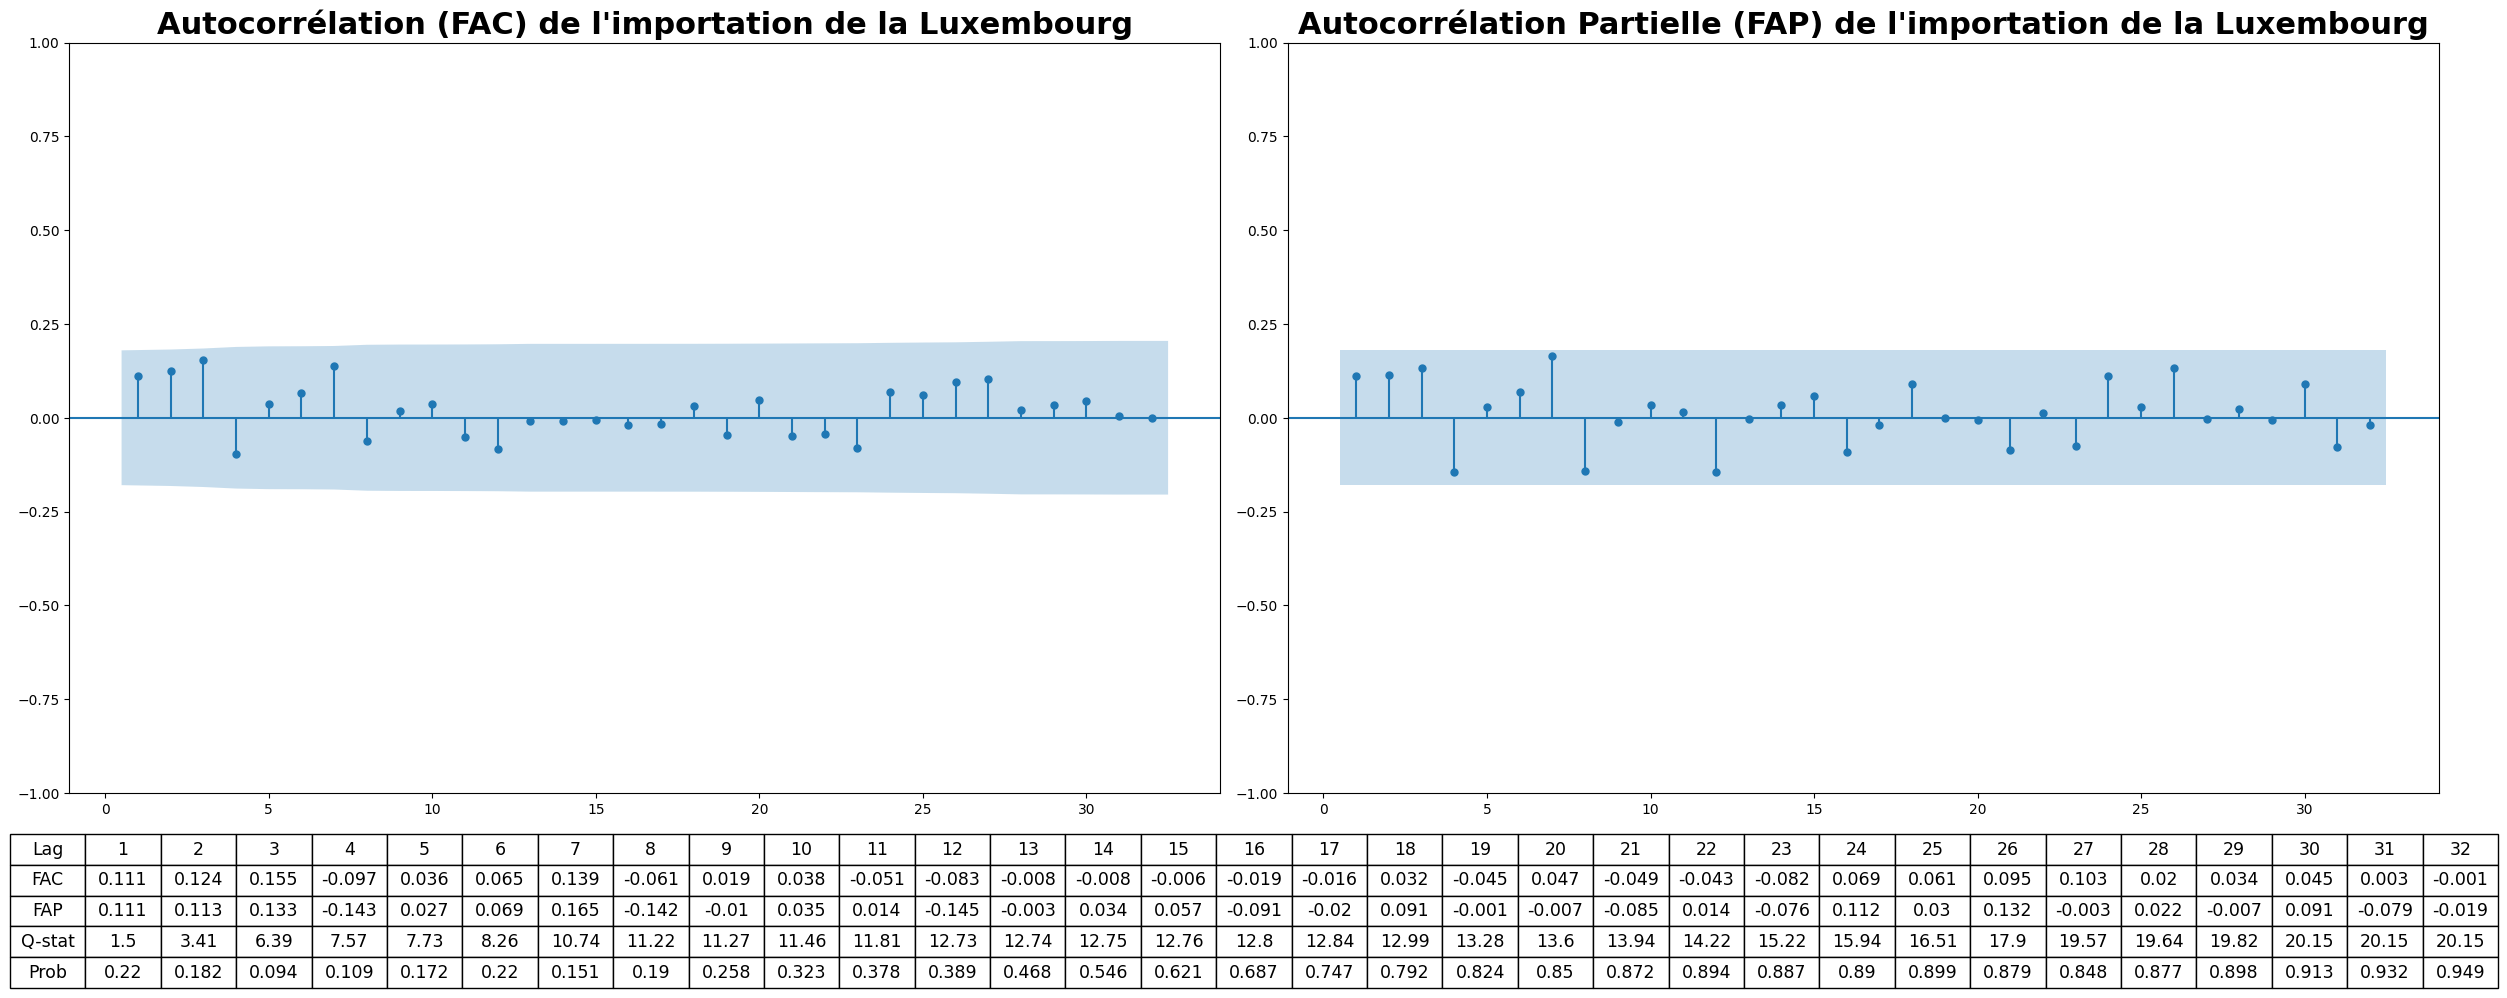

In [83]:
MDG = MTD.set_index('Lag').T
MDG = MDG.reset_index().rename(columns={'index': 'Lag'})  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(M_diff, lags=32, zero=False,
                         title="Autocorrélation (FAC) de l'exportation de la Luxembourg", ax=ax0)
ax0.set_title("Autocorrélation (FAC) de l'importation de la Luxembourg", fontsize=22, fontweight='bold')

ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(M_diff, lags=32, zero=False,
                          title="Autocorrélation Partielle (FAP) de l'exportation de la Luxembourg", ax=ax1)
ax1.set_title("Autocorrélation Partielle (FAP) de l'importation de la Luxembourg", fontsize=22, fontweight='bold')
# Tableau en bas là
ax2 = fig.add_subplot(gs[1, :])
ax2.axis("off")

table = ax2.table(cellText=MDG.values,
                  colLabels=MDG.columns,
                  cellLoc='center',
                  loc='upper center')
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
#plt.savefig('MDiffGraph+Table.png', bbox_inches='tight')
plt.show()

# PARTIE 2 : Modèle multivariée

## Causalité de Granger

In [84]:
XMD = XM.diff().fillna(0).rename(columns={'lnX':'ΔlnX','lnM':'ΔlnM'})
VARXMD = VAR(XMD)

In [85]:
VARXMD_1 = VARXMD.fit(1)
VARXMD_1.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 12, Sep, 2025
Time:                     19:55:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -15.0532
Nobs:                     119.000    HQIC:                  -15.1364
Log likelihood:           572.292    FPE:                2.52147e-07
AIC:                     -15.1933    Det(Omega_mle):     2.39899e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.007525         0.002409            3.124           0.002
L1.ΔlnX         0.468582         0.129499            3.618           0.000
L1.ΔlnM        -0.113459         0.100114           -1.133           0.257

Results f

In [86]:
VARXMD_2 = VARXMD.fit(2)
VARXMD_2.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 12, Sep, 2025
Time:                     19:55:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -15.0526
Nobs:                     118.000    HQIC:                  -15.1921
Log likelihood:           577.090    FPE:                2.29503e-07
AIC:                     -15.2875    Det(Omega_mle):     2.11224e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.005101         0.002496            2.044           0.041
L1.ΔlnX         0.418492         0.128001            3.269           0.001
L1.ΔlnM        -0.142817         0.103709           -1.377           0.168
L2.ΔlnX   

In [87]:
VARXMD_3 = VARXMD.fit(3)
VARXMD_3.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 12, Sep, 2025
Time:                     19:55:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -14.9300
Nobs:                     117.000    HQIC:                  -15.1264
Log likelihood:           574.710    FPE:                2.35806e-07
AIC:                     -15.2605    Det(Omega_mle):     2.09935e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.004954         0.002625            1.887           0.059
L1.ΔlnX         0.407490         0.135577            3.006           0.003
L1.ΔlnM        -0.125042         0.110014           -1.137           0.256
L2.ΔlnX   

In [88]:
VARXMD_4 = VARXMD.fit(4)
VARXMD_4.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 12, Sep, 2025
Time:                     19:55:00
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -14.8682
Nobs:                     116.000    HQIC:                  -15.1221
Log likelihood:           575.946    FPE:                2.27779e-07
AIC:                     -15.2955    Det(Omega_mle):     1.96159e-07
--------------------------------------------------------------------
Results for equation ΔlnX
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.006224         0.002755            2.259           0.024
L1.ΔlnX         0.409002         0.138890            2.945           0.003
L1.ΔlnM        -0.119863         0.112582           -1.065           0.287
L2.ΔlnX   

In [89]:
VARXMD_2.test_causality('ΔlnX', ['ΔlnM'], kind='wald',signif=0.05).summary()

Test statistic,Critical value,p-value,df
3.604,5.991,0.165,2


In [90]:
VARXMD_2.test_causality('ΔlnX', ['ΔlnX'], kind='wald', signif=0.01).summary()

Test statistic,Critical value,p-value,df
12.03,9.210,0.002,2


In [91]:
VARXMD_2.test_causality('ΔlnM', ['ΔlnX'], kind='wald',signif=0.1).summary()

Test statistic,Critical value,p-value,df
37.23,4.605,0.000,2


In [92]:
VARXMD_2.test_causality('ΔlnM', ['ΔlnM'], kind='wald',signif=0.05).summary()

Test statistic,Critical value,p-value,df
15.80,5.991,0.000,2


In [93]:
GTXM = VARXMD_2.test_causality('ΔlnX', ['ΔlnM'], kind='wald',signif=0.05).summary().as_text()
GTXX = VARXMD_2.test_causality('ΔlnX', ['ΔlnX'], kind='wald', signif=0.01).summary().as_text()
GTMX = VARXMD_2.test_causality('ΔlnM', ['ΔlnX'], kind='wald',signif=0.1).summary().as_text()
GTMM = VARXMD_2.test_causality('ΔlnM', ['ΔlnM'], kind='wald',signif=0.05).summary().as_text()
GTALL = {'GTXM', 'GTXX', 'GTMX', 'GTMM'}
GTTEXT = 'TestGranger_{}.txt'

for n in GTALL:
    # Obtenez le contenu de la variable
    content = globals()[n]
    with open(GTTEXT.format(n), 'w') as file:
        file.write(f"{content}\n")

In [94]:
Test = grangercausalitytests(XMD, 2 ,addconst=True, verbose=None)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.2844  , p=0.2594  , df_denom=116, df_num=1
ssr based chi2 test:   chi2=1.3176  , p=0.2510  , df=1
likelihood ratio test: chi2=1.3103  , p=0.2523  , df=1
parameter F test:         F=1.2844  , p=0.2594  , df_denom=116, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.8019  , p=0.1697  , df_denom=113, df_num=2
ssr based chi2 test:   chi2=3.7633  , p=0.1523  , df=2
likelihood ratio test: chi2=3.7045  , p=0.1569  , df=2
parameter F test:         F=1.8019  , p=0.1697  , df_denom=113, df_num=2


# PARTIE 3 : Cointégration

### MCO de la régression des exportations sur les  importations

In [95]:
x2 = sm.add_constant(M['M'])
y2 = X['X']

modelXM = sm.OLS(y2, x2).fit()
print(modelXM.summary())
with open('modelXM.txt', 'w') as f:
    f.write(modelXM.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                      X   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 4.086e+04
Date:                Fri, 12 Sep 2025   Prob (F-statistic):          9.27e-152
Time:                        19:55:00   Log-Likelihood:                 280.12
No. Observations:                 120   AIC:                            -556.2
Df Residuals:                     118   BIC:                            -550.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8475      0.044     19.356      0.0

### Résidu du MCO Exp sur Imp

In [96]:
Residuxm = modelXM.resid

ResiduXM = pd.DataFrame({
    'Valeurs_ajustées': modelXM.fittedvalues,
    'u': Residuxm
})

### MCO de la régression des importations sur les exportations

In [97]:
x1 = sm.add_constant(X['X'])
y1 = M['M']

modelMX = sm.OLS(y1, x1).fit()
print(modelMX.summary())
with open('modelMX.txt', 'w') as f:
    f.write(modelMX.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                      M   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 4.086e+04
Date:                Fri, 12 Sep 2025   Prob (F-statistic):          9.27e-152
Time:                        19:55:01   Log-Likelihood:                 271.88
No. Observations:                 120   AIC:                            -539.8
Df Residuals:                     118   BIC:                            -534.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8791      0.051    -17.134      0.0

### Résidu du MCO Imp sur Exp

In [98]:
Residumx = modelMX.resid

ResiduMX = pd.DataFrame({
    'Valeurs_ajustées': modelMX.fittedvalues,
    'u': Residumx
})

### Graphique des résidus

In [99]:
ResiduXMG = ResiduXM.drop('Valeurs_ajustées',axis =1)
ResiduXMGFlat = np.array(ResiduXMG).flatten()

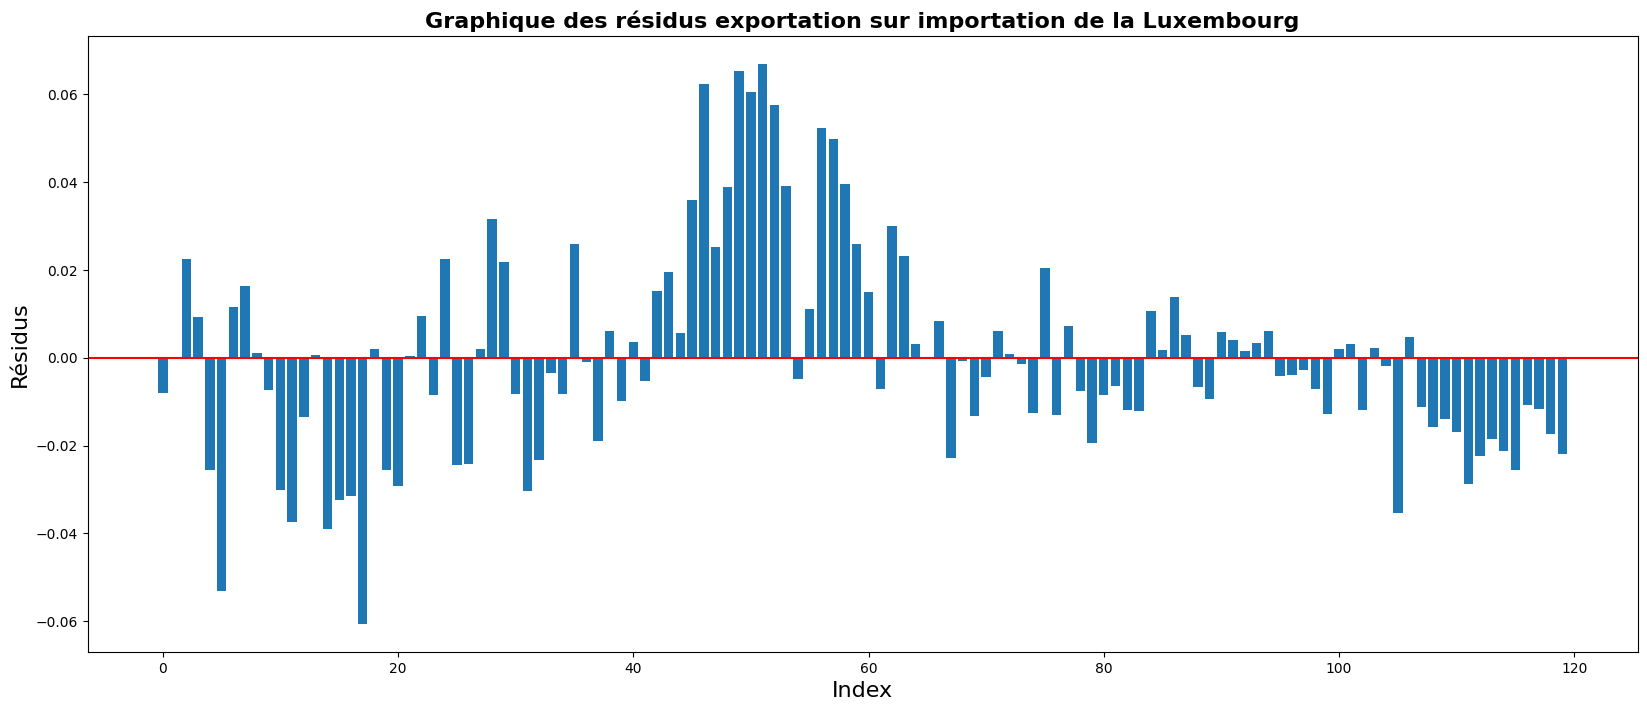

In [100]:
plt.figure(figsize=(20, 8))
plt.bar(range(len(ResiduXMGFlat)), ResiduXMGFlat)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Index', fontsize=16)
plt.ylabel('Résidus', fontsize=16)
plt.title('Graphique des résidus exportation sur importation de la Luxembourg', fontsize=16, fontweight='bold')
plt.savefig('GraphRésXM.png', bbox_inches='tight')

In [101]:
ResiduMXG = ResiduMX.drop('Valeurs_ajustées', axis=1)
ResiduMXGFlat = np.array(ResiduMXG).flatten()

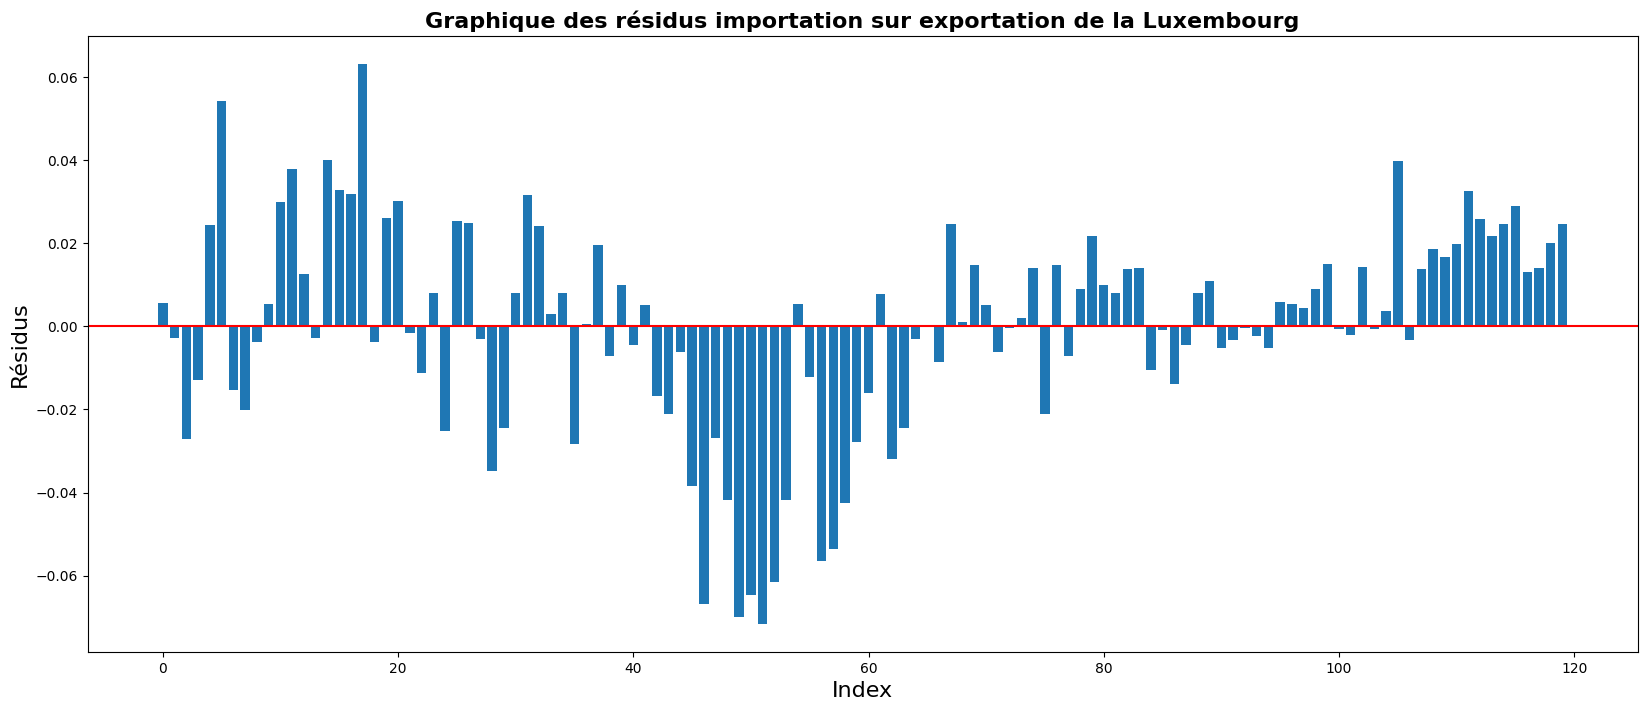

In [102]:
plt.figure(figsize=(20, 8))
plt.bar(range(len(ResiduMXGFlat)), ResiduMXGFlat)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Index', fontsize=16)
plt.ylabel('Résidus', fontsize=16)
plt.title('Graphique des résidus importation sur exportation de la Luxembourg', fontsize=16, fontweight='bold')
plt.savefig('GraphRésMX.png', bbox_inches='tight')

### Tableau résidu

In [103]:
TRXM = ResiduXMG.rename(columns={'u': 'uXM'})
TRMX = ResiduMXG.rename(columns={'u': 'uMX'})
TableauRésXM = TRXM.join(TRMX) 

In [104]:
TableauRésXM.to_csv("TableauRésXM.csv", index=True)

with open('TableauRésXM.txt', 'a') as f:
    f.write(TableauRésXM.to_string(header=False, index=False))

### FAC et FAP des résidus ΔuXM et ΔuMX

In [105]:
ΔuXM_fac = acf(ResiduXMG, adjusted=0, nlags=32, qstat=True, fft=True, alpha=None, bartlett_confint=True, missing='none')
ΔuXMT = pd.DataFrame(ΔuXM_fac).T.rename(columns={0:'FAC',1:'Q-stat',2:'Prob'})
ΔuXM_fap = pacf(ResiduXMG, nlags=32, method='ywmle', alpha=None)
ΔuXTFAP = pd.DataFrame(ΔuXM_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0:'FAP'})
ΔuXMT.insert(1, "FAP", ΔuXTFAP )
ΔuXMT.iloc[:, 0] = ΔuXMT.iloc[:, 0].shift(-1)
ΔuXMT = ΔuXMT.drop(ΔuXMT.index[-1]).reset_index(drop=True)
 
ΔuXMT[['FAC', 'FAP', 'Prob']] = ΔuXMT[['FAC', 'FAP','Prob']].round(3)
 
ΔuXMT[['Q-stat']] = ΔuXMT[['Q-stat']].round(2)

ΔuXMT.insert(0, 'Lag', range(1, len(ΔuXMT) + 1))

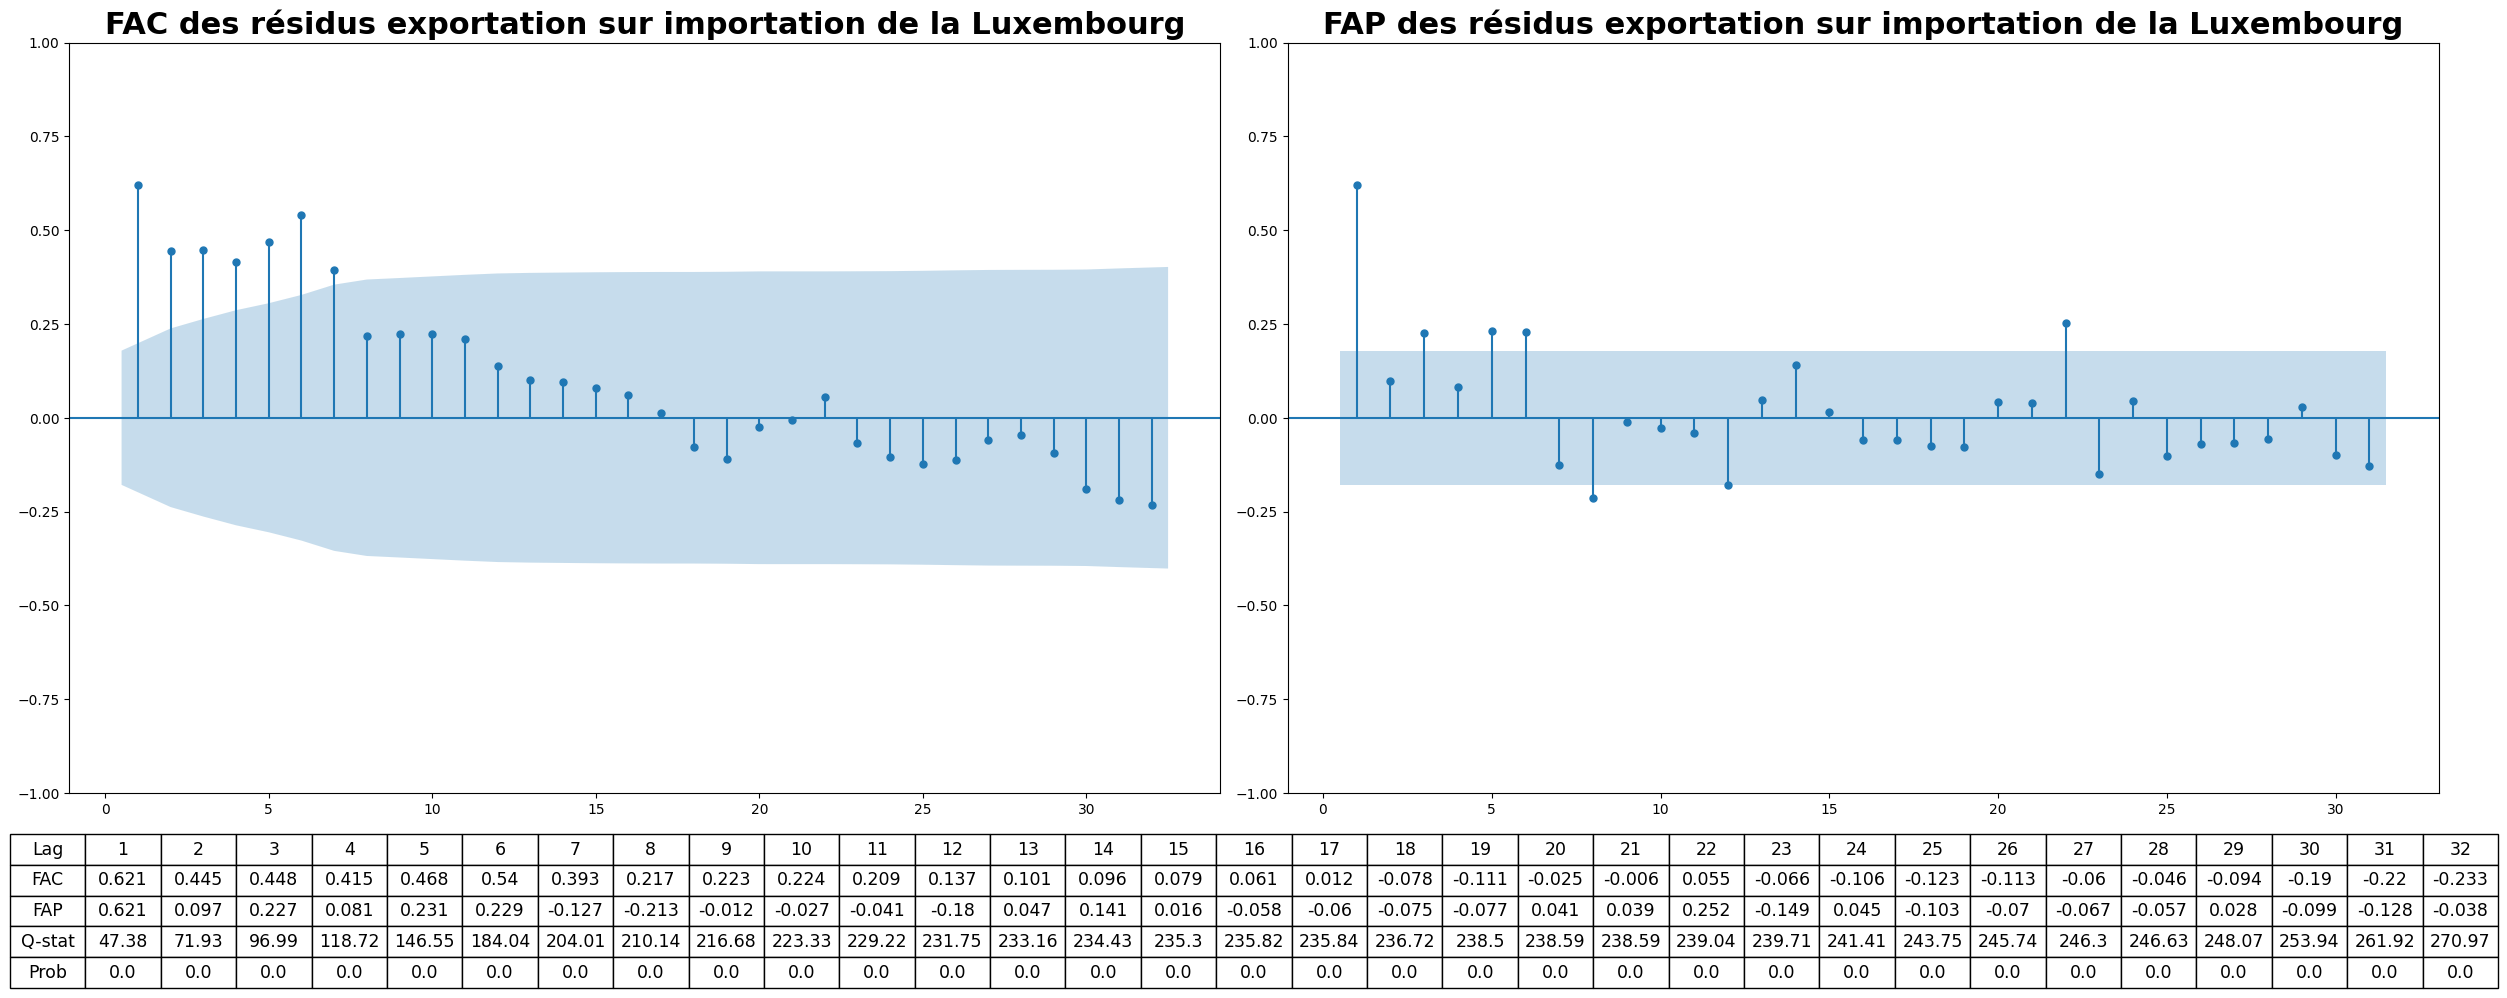

In [106]:
XG = ΔuXMT.set_index('Lag').T
XG = XG.reset_index().rename(columns={'index': 'Lag'})  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(ResiduXMG, lags=32, zero=False, ax=ax0)
ax0.set_title("FAC des résidus exportation sur importation de la Luxembourg", fontsize=22, fontweight='bold')
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(ResiduXMG, lags=31, zero=False, ax=ax1)
ax1.set_title("FAP des résidus exportation sur importation de la Luxembourg", fontsize=22, fontweight='bold')
# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis('off')

table = ax2.table(cellText=XG.values,
                  colLabels=XG.columns,
                  cellLoc='center',
                  loc='upper center')
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)

plt.tight_layout()
plt.savefig('ΔuXMTGraph+Table.png', bbox_inches='tight')
plt.show()

In [107]:
ΔuMX_fac = acf(ResiduMXG, adjusted=0, nlags=32, qstat=True, fft=True, alpha=None, bartlett_confint=True, missing='none')
ΔuMXT = pd.DataFrame(ΔuMX_fac).T.rename(columns={0:'FAC',1:'Q-stat',2:'Prob'})
ΔuMX_fap = pacf(ResiduMXG, nlags=32, method='ywmle', alpha=None)
ΔuMXTFAP = pd.DataFrame(ΔuMX_fap).iloc[1:, :].reset_index(drop=True).rename(columns={0:'FAP'})
ΔuMXT.insert(1, "FAP", ΔuMXTFAP )
ΔuMXT.iloc[:, 0] = ΔuMXT.iloc[:, 0].shift(-1)
ΔuMXT = ΔuMXT.drop(ΔuMXT.index[-1]).reset_index(drop=True)

ΔuMXT[['FAC', 'FAP', 'Prob']] = ΔuMXT[['FAC', 'FAP','Prob']].round(3)
 
ΔuMXT[['Q-stat']] = ΔuMXT[['Q-stat']].round(2)

ΔuMXT.insert(0, 'Lag', range(1, len(ΔuMXT) + 1))

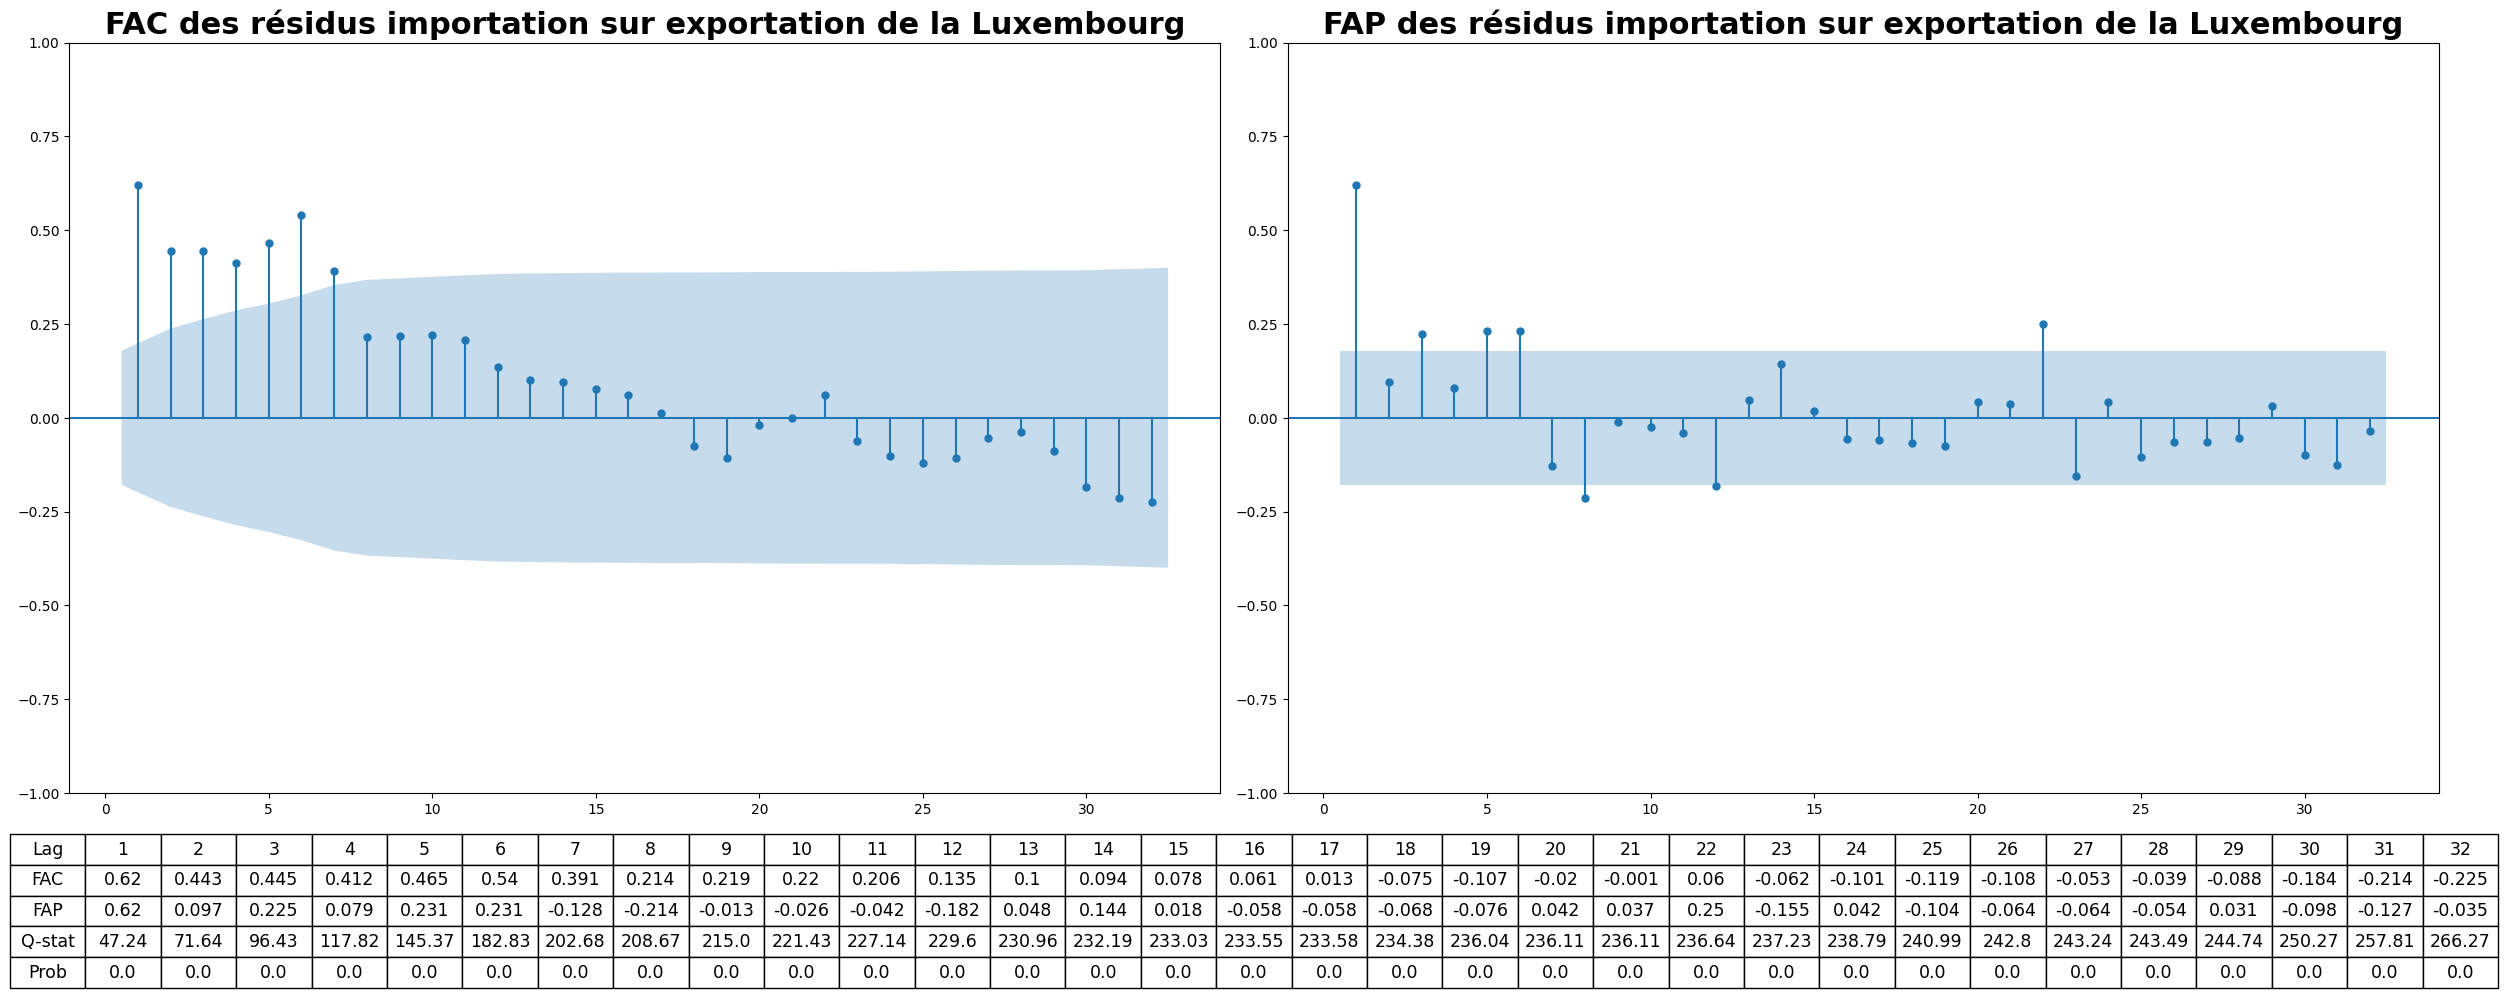

In [108]:
MG = ΔuMXT.set_index('Lag').T
MG = MG.reset_index().rename(columns={'index': 'Lag'})  # Important pour afficher FAC/FAP/etc
# Créer la figure avec GridSpec
fig = plt.figure(figsize=(25, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[20, 3])
# Graphiques
ax0 = fig.add_subplot(gs[0, 0])
sm.graphics.tsa.plot_acf(ResiduMXG, lags=32, zero=False, ax=ax0)
ax0.set_title("FAC des résidus importation sur exportation de la Luxembourg", fontsize=22, fontweight='bold')
ax1 = fig.add_subplot(gs[0, 1])
sm.graphics.tsa.plot_pacf(ResiduMXG, lags=32, zero=False, ax=ax1)
ax1.set_title("FAP des résidus importation sur exportation de la Luxembourg", fontsize=22, fontweight='bold')

# Tableau en bas
ax2 = fig.add_subplot(gs[1, :])
ax2.axis('off')

table = ax2.table(cellText=MG.values,
                  colLabels=MG.columns,
                  cellLoc='center',
                  loc='upper center')
table.scale(1.05, 1.5)
table.auto_set_font_size(False)
table.set_fontsize(12.5)
plt.tight_layout()
plt.savefig('ΔuMXTGraph+Table.png', bbox_inches='tight')
plt.show()

### Regréssions

In [109]:
def retard(df, column_name, n):
    """
    Applique des décalages à une colonne d'un DataFrame et ajoute les colonnes décalées.

    :param df: DataFrame pandas
    :param column_name: Nom de la colonne à décaler
    :param n: Nombre de décalages à appliquer
    :return: DataFrame avec les colonnes décalées ajoutées
    """
    for i in range(1, n + 1):
        df[f'{column_name}(-{i})'] = df[column_name].shift(i, fill_value=0)
    return df

In [110]:
ResiduXM_D = ResiduXM.drop('Valeurs_ajustées', axis=1)
ResiduXM_D = ResiduXM_D.diff().fillna(0).rename(columns={'u':'Δu'})
ResiduXM_D = retard(ResiduXM_D, 'Δu', 4)
ResiduXM_R = ResiduXM.shift(fill_value=0).rename(columns={'u':'u(-1)'}).drop('Valeurs_ajustées', axis=1)
ResiduXM_M = ResiduXM_R.join(ResiduXM_D, how='left').rename(columns={'Δu':'ΔuXM'})
print(ResiduXM_M)

            u(-1)      ΔuXM    Δu(-1)    Δu(-2)    Δu(-3)    Δu(-4)
1995-Q1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1995-Q2 -0.007985  0.007869  0.000000  0.000000  0.000000  0.000000
1995-Q3 -0.000116  0.022681  0.007869  0.000000  0.000000  0.000000
1995-Q4  0.022565 -0.013235  0.022681  0.007869  0.000000  0.000000
1996-Q1  0.009330 -0.034844 -0.013235  0.022681  0.007869  0.000000
...           ...       ...       ...       ...       ...       ...
2023-Q4 -0.021134 -0.004361 -0.002525  0.003667  0.006390 -0.011838
2024-Q1 -0.025495  0.014826 -0.004361 -0.002525  0.003667  0.006390
2024-Q2 -0.010669 -0.000984  0.014826 -0.004361 -0.002525  0.003667
2024-Q3 -0.011653 -0.005713 -0.000984  0.014826 -0.004361 -0.002525
2024-Q4 -0.017365 -0.004533 -0.005713 -0.000984  0.014826 -0.004361

[120 rows x 6 columns]


In [111]:
ResiduMX_D = ResiduMX.drop('Valeurs_ajustées', axis=1)
ResiduMX_D = ResiduMX_D.diff().fillna(0).rename(columns={'u':'Δu'})
ResiduMX_D = retard(ResiduMX_D, 'Δu', 4)
ResiduMX_R = ResiduMX.shift(fill_value=0).rename(columns={'u':'u(-1)'}).drop('Valeurs_ajustées', axis=1)
ResiduMX_M = ResiduMX_R.join(ResiduMX_D, how='left').rename(columns={'Δu':'ΔuMX'})
print(ResiduMX_M)

            u(-1)      ΔuMX    Δu(-1)    Δu(-2)    Δu(-3)    Δu(-4)
1995-Q1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1995-Q2  0.005540 -0.008416  0.000000  0.000000  0.000000  0.000000
1995-Q3 -0.002877 -0.024227 -0.008416  0.000000  0.000000  0.000000
1995-Q4 -0.027104  0.014170 -0.024227 -0.008416  0.000000  0.000000
1996-Q1 -0.012934  0.037437  0.014170 -0.024227 -0.008416  0.000000
...           ...       ...       ...       ...       ...       ...
2023-Q4  0.024530  0.004556  0.002723 -0.003943 -0.006843  0.012731
2024-Q1  0.029086 -0.016042  0.004556  0.002723 -0.003943 -0.006843
2024-Q2  0.013044  0.000954 -0.016042  0.004556  0.002723 -0.003943
2024-Q3  0.013998  0.005966  0.000954 -0.016042  0.004556  0.002723
2024-Q4  0.019964  0.004775  0.005966  0.000954 -0.016042  0.004556

[120 rows x 6 columns]


## Nombre de retard à prendre pour la VECM

### Exportation sur Importation XM

In [112]:
XMy= ResiduXM_M['ΔuXM']

In [113]:
XMx4= ResiduXM_M[['u(-1)','Δu(-1)','Δu(-2)','Δu(-3)','Δu(-4)']]
XMx4= sm.add_constant(XMx4)

modelXM4= sm.OLS(XMy, XMx4).fit()

In [114]:
XMx3 = ResiduXM_M[['u(-1)','Δu(-1)','Δu(-2)','Δu(-3)']]
XMx3 = sm.add_constant(XMx3)

modelXM3 = sm.OLS(XMy, XMx3).fit()

In [115]:
XMx2 = ResiduXM_M[['u(-1)','Δu(-1)','Δu(-2)']]
XMx2 = sm.add_constant(XMx2)

modelXM2 = sm.OLS(XMy, XMx2).fit()

In [116]:
XMx1= ResiduXM_M[['u(-1)','Δu(-1)']]
XMx1= sm.add_constant(XMx1)

modelXM1= sm.OLS(XMy, XMx1).fit()

In [117]:
XMx0 = ResiduXM_M[['u(-1)']]
XMx0 = sm.add_constant(XMx0)

modelXM0 = sm.OLS(XMy, XMx0).fit()

### Importation sur Exportation MX

In [118]:
MXy= ResiduMX_M['ΔuMX']

In [119]:
MXx4= ResiduMX_M[['u(-1)','Δu(-1)','Δu(-2)','Δu(-3)','Δu(-4)']]
MXx4= sm.add_constant(MXx4)

modelMX4= sm.OLS(MXy, MXx4).fit()

In [120]:
MXx3 = ResiduMX_M[['u(-1)','Δu(-1)','Δu(-2)','Δu(-3)']]
MXx3 = sm.add_constant(MXx3)

modelMX3 = sm.OLS(MXy, MXx3).fit()

In [121]:
MXx2 = ResiduMX_M[['u(-1)','Δu(-1)','Δu(-2)']]
MXx2 = sm.add_constant(MXx2)

modelMX2 = sm.OLS(MXy, MXx2).fit()

In [122]:
MXx1= ResiduMX_M[['u(-1)','Δu(-1)']]
MXx1= sm.add_constant(MXx1)

modelMX1= sm.OLS(MXy, MXx1).fit()

In [123]:
MXx0 = ResiduMX_M[['u(-1)']]
MXx0 = sm.add_constant(MXx0)

modelMX0 = sm.OLS(MXy, MXx0).fit()

In [124]:
for i in range(5):
    model_name = f"modelXM{i}"
    file_name = f"{model_name}.txt"
    current_model = globals()[model_name]
    text = current_model.summary().as_text()
    with open(file_name, 'w') as file:
        file.write(text)

    print(f"Le modèle {model_name} a été sauvegardé dans {file_name}")

Le modèle modelXM0 a été sauvegardé dans modelXM0.txt
Le modèle modelXM1 a été sauvegardé dans modelXM1.txt
Le modèle modelXM2 a été sauvegardé dans modelXM2.txt
Le modèle modelXM3 a été sauvegardé dans modelXM3.txt
Le modèle modelXM4 a été sauvegardé dans modelXM4.txt


In [125]:
for i in range(5):
    model_name = f"modelMX{i}"
    file_name = f"{model_name}.txt"
    current_model = globals()[model_name]
    text = current_model.summary().as_text()
    with open(file_name, 'w') as file:
        file.write(text)

    print(f"Le modèle {model_name} a été sauvegardé dans {file_name}")

Le modèle modelMX0 a été sauvegardé dans modelMX0.txt
Le modèle modelMX1 a été sauvegardé dans modelMX1.txt
Le modèle modelMX2 a été sauvegardé dans modelMX2.txt
Le modèle modelMX3 a été sauvegardé dans modelMX3.txt
Le modèle modelMX4 a été sauvegardé dans modelMX4.txt


In [126]:
from statsmodels.tsa.vector_ar.vecm import VECM

serie = pd.concat([X, M], axis=1)
serie.columns = ["logX", "logM"]

vecm = VECM(serie, k_ar_diff=2, coint_rank=1, deterministic="co")
vecm_res = vecm.fit()
print(vecm_res.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation logX
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1943      0.099      1.967      0.049       0.001       0.388
L1.logX        0.5104      0.133      3.841      0.000       0.250       0.771
L1.logM       -0.2485      0.115     -2.161      0.031      -0.474      -0.023
L2.logX        0.2471      0.141      1.746      0.081      -0.030       0.524
L2.logM        0.0144      0.106      0.136      0.892      -0.194       0.223
Det. terms outside the coint. relation & lagged endog. parameters for equation logM
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0373      0.124     -0.301      0.764      -0.280       0.206
L1.logX        0.8357      0.167      5.00

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [127]:
text = vecm_res.summary().as_text()
with open('vecm.txt', 'w') as file:
    file.write(text)

## Partie 4

### Prévision

In [128]:
model = VECM(serie, k_ar_diff=2, coint_rank=1, deterministic="co")
model_fit = model.fit()

# Get the last `k_ar` observations (model's lag order)
lag_order = model.k_ar_diff
last_obs = serie.values[-lag_order:]


forecast = vecm_res.predict(steps=8)


forecast_df = pd.DataFrame(forecast, columns=serie.columns)

print(forecast_df)

        logX      logM
0  10.079189  9.917391
1  10.077504  9.913139
2  10.080575  9.916934
3  10.087302  9.922924
4  10.096405  9.931665
5  10.106764  9.942497
6  10.117791  9.954014
7  10.129241  9.965972


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [129]:
#Formater le dataframe forecast_df comme serie

# Générer la liste des nouveaux labels
quarters = [f"{year}-Q{quarter}" for year in [2025, 2026] for quarter in range(1, 5)]

# Affecter cette liste comme nouvel index
forecast_df.index = quarters

# Vérifier le résultat
print(forecast_df)

              logX      logM
2025-Q1  10.079189  9.917391
2025-Q2  10.077504  9.913139
2025-Q3  10.080575  9.916934
2025-Q4  10.087302  9.922924
2026-Q1  10.096405  9.931665
2026-Q2  10.106764  9.942497
2026-Q3  10.117791  9.954014
2026-Q4  10.129241  9.965972


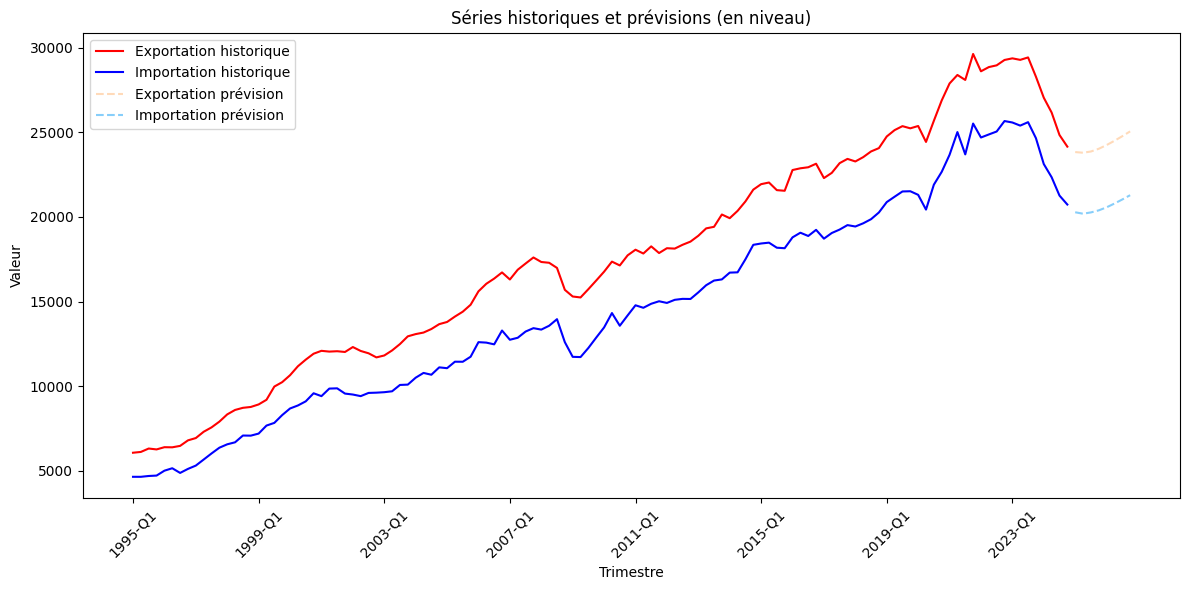

In [130]:
#Graph mais avant on doit passer les série de log à niveau avec l'exponentiel

# Appliquer np.exp colonne par colonne et garder l'index avec pandas
serie_exp = serie.copy()
serie_exp['logX'] = np.exp(serie['logX'])
serie_exp['logM'] = np.exp(serie['logM'])

forecast_exp = forecast_df.copy()
forecast_exp['logX'] = np.exp(forecast_df['logX'])
forecast_exp['logM'] = np.exp(forecast_df['logM'])

# Maintenant on peut tracer avec l'index conservé
plt.figure(figsize=(12,6))

plt.plot(serie_exp.index, serie_exp['logX'], label='Exportation historique', color='red', linestyle='-')
plt.plot(serie_exp.index, serie_exp['logM'], label='Importation historique', color='blue', linestyle='-')
plt.plot(forecast_exp.index, forecast_exp['logX'], label='Exportation prévision', color='peachpuff', linestyle='--')
plt.plot(forecast_exp.index, forecast_exp['logM'], label='Importation prévision', color='lightskyblue', linestyle='--')

# Pour gérer les ticks x, on prend un tick tous les 16 trimestres (4 ans)
ticks_to_use = serie_exp.index.union(forecast_exp.index)[::16]

plt.xticks(ticks_to_use, rotation=45)  # on affiche seulement ces ticks avec rotation


plt.title("Séries historiques et prévisions (en niveau)")
plt.xlabel("Trimestre")
plt.ylabel("Valeur")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_9941/3441648484.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  serie_exp.index = pd.to_datetime(serie_exp.index)
/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_9941/3441648484.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  forecast_exp.index = pd.to_datetime(forecast_exp.index)


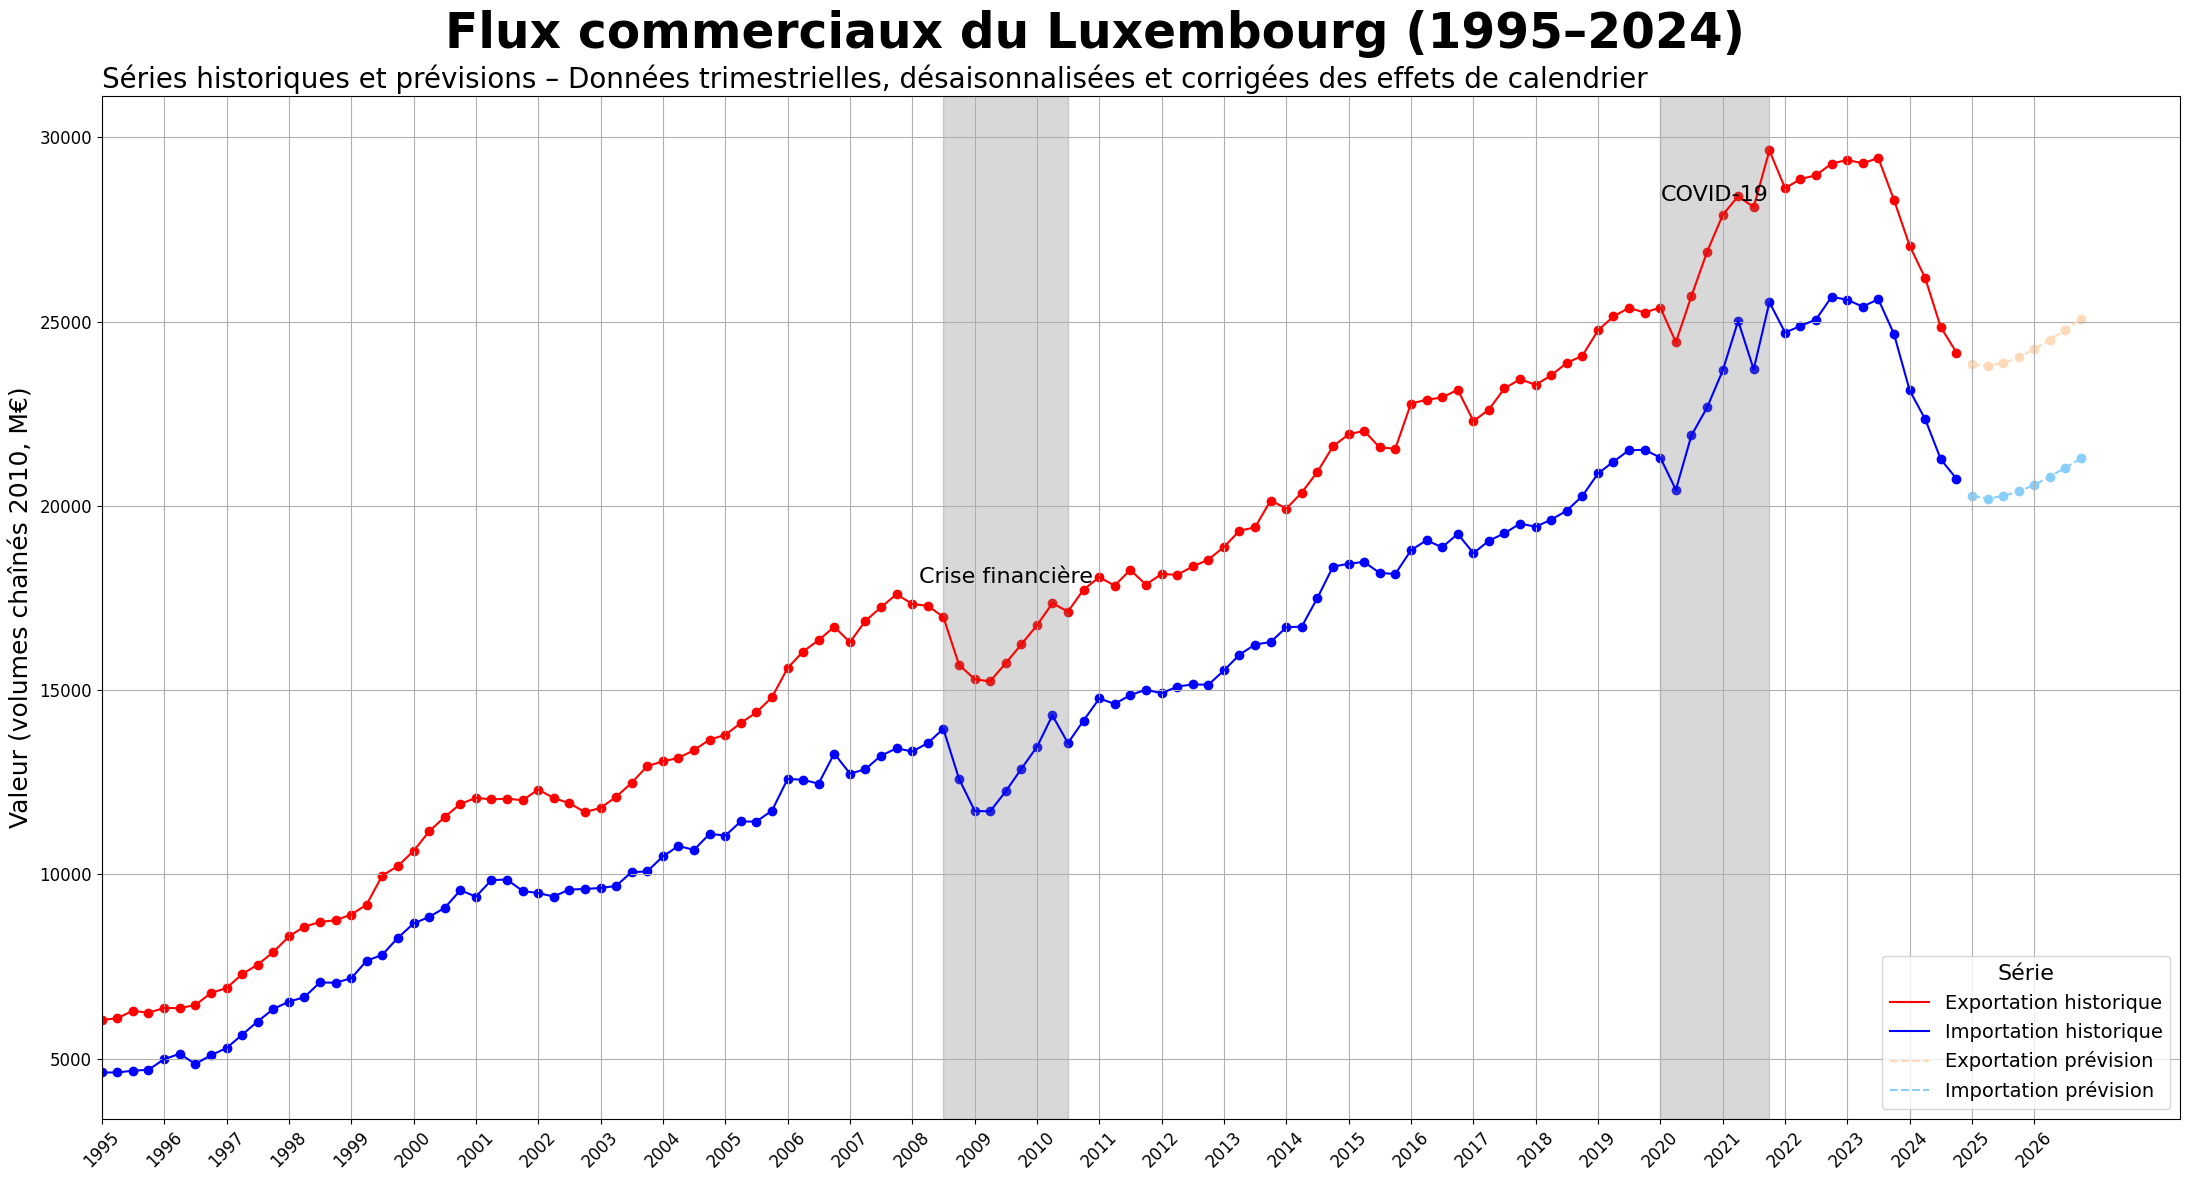

In [131]:
#Même graphique mais en mieux

# Exponentiation des séries
serie_exp = serie.copy()
serie_exp['logX'] = np.exp(serie['logX'])
serie_exp['logM'] = np.exp(serie['logM'])

forecast_exp = forecast_df.copy()
forecast_exp['logX'] = np.exp(forecast_df['logX'])
forecast_exp['logM'] = np.exp(forecast_df['logM'])

# S'assurer que l'index est bien en datetime
serie_exp.index = pd.to_datetime(serie_exp.index)
forecast_exp.index = pd.to_datetime(forecast_exp.index)

# Fusion des index pour définir les ticks
full_index = serie_exp.index.union(forecast_exp.index)

# Création de la figure
plt.figure(figsize=(22, 12))

# Courbes historiques
plt.plot(serie_exp.index, serie_exp['logX'], label='Exportation historique', color='red', linestyle='-')
plt.plot(serie_exp.index, serie_exp['logM'], label='Importation historique', color='blue', linestyle='-')

# Courbes prévisionnelles
plt.plot(forecast_exp.index, forecast_exp['logX'], label='Exportation prévision', color='peachpuff', linestyle='--')
plt.plot(forecast_exp.index, forecast_exp['logM'], label='Importation prévision', color='lightskyblue', linestyle='--')

# Points historiques
plt.scatter(serie_exp.index, serie_exp['logX'], color='red')
plt.scatter(serie_exp.index, serie_exp['logM'], color='blue')

# Points prévisionnels
plt.scatter(forecast_exp.index, forecast_exp['logX'], color='peachpuff')
plt.scatter(forecast_exp.index, forecast_exp['logM'], color='lightskyblue')

# Définir la hauteur max pour annotations
y_max = max(serie_exp[['logX', 'logM']].max().max(), forecast_exp[['logX', 'logM']].max().max())
plt.ylim(top=y_max * 1.05)

# Zones grisées pour les crises
crise_fin_start = pd.Timestamp("2008-07-01")
crise_fin_end = pd.Timestamp("2010-06-30")
covid_start = pd.Timestamp("2020-01-01")
covid_end = pd.Timestamp("2021-09-30")

plt.axvspan(crise_fin_start, crise_fin_end, color='grey', alpha=0.3)
plt.axvspan(covid_start, covid_end, color='grey', alpha=0.3)

# Annotations des crises
plt.text(x=crise_fin_start + (crise_fin_end - crise_fin_start) / 2,
         y=y_max * 0.6,
         s="Crise financière",
         fontsize=16,
         ha='center',
         va='bottom',
         color='black')

plt.text(x=covid_start + (covid_end - covid_start) / 2,
         y=y_max * 0.95,
         s="COVID-19",
         fontsize=16,
         ha='center',
         va='bottom',
         color='black')

# Titres et labels
plt.xlabel(None)
plt.ylabel("Valeur (volumes chaînés 2010, M€)", fontsize=18)
plt.title("Séries historiques et prévisions – Données trimestrielles, désaisonnalisées et corrigées des effets de calendrier", fontsize=20, loc='left')
plt.suptitle("Flux commerciaux du Luxembourg (1995–2024)", fontsize=35, fontweight='bold')

# Légende
plt.legend(title="Série", title_fontsize=16, fontsize=14, loc='lower right', bbox_to_anchor=(1, 0))

# Grille
plt.grid(True)

# Axe des x – affichage des années
plt.xlim(left=pd.Timestamp("1995-01-01"))
plt.xticks(pd.date_range(start="1995-01-01", end=full_index.max(), freq="YS"), fontsize=12, rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Axe des y
plt.yticks(fontsize=12)

# Affichage
plt.tight_layout()
plt.show()

### Comment présenter les résultats en tableau ?

In [132]:
forecast_exp.columns = ['Exportation', 'Importation']
forecast_exp = forecast_exp.round(2)

# Renommer l’index s’il a un sens (optionnel)
forecast_exp.index.name = "Annee"  # ou "Ligne", "Index", etc.

# Convertir en HTML avec les lignes (index)
html_table = forecast_exp.to_html(index=True)

# Sauvegarder dans un fichier HTML
with open("tableau_forecast.html", "w") as f:
    f.write(html_table)


### Taux de croissance

In [133]:
# Calculer le taux de croissance pour les variables prévisionnelles en niveau
growth_rates = forecast_exp[['Exportation', 'Importation']].pct_change()

# Renommer les colonnes pour refléter qu'il s'agit de taux de croissance
growth_rates.columns = ['growth_X', 'growth_M']

# Afficher les résultats
print(growth_rates)

growth_rates_percent = growth_rates * 100

# Afficher les résultats
print(growth_rates_percent)


            growth_X  growth_M
Annee                         
2025-01-01       NaN       NaN
2025-04-01 -0.001684 -0.004243
2025-07-01  0.003076  0.003802
2025-10-01  0.006749  0.006007
2026-01-01  0.009145  0.008780
2026-04-01  0.010413  0.010891
2026-07-01  0.011088  0.011584
2026-10-01  0.011516  0.012030
            growth_X  growth_M
Annee                         
2025-01-01       NaN       NaN
2025-04-01 -0.168361 -0.424309
2025-07-01  0.307586  0.380213
2025-10-01  0.674940  0.600718
2026-01-01  0.914467  0.877969
2026-04-01  1.041324  1.089076
2026-07-01  1.108811  1.158370
2026-10-01  1.151575  1.203005


In [134]:
growth_rates_percent = growth_rates_percent.round(2)

# Renommer l’index s’il a un sens (optionnel)
growth_rates_percent.index.name = "Annee"  # ou "Ligne", "Index", etc.

# Convertir en HTML avec les lignes (index)
html_table = growth_rates_percent.to_html(index=True)

# Sauvegarder dans un fichier HTML
with open("tableau_forecast_growth.html", "w") as f:
    f.write(html_table)

# Fin